# Part 2: EDA & Prescriptive Analysis - DATATHON 2026

**Team:** GenCore | **Lead:** Trịnh Hoàng Tú

**Objective:** Extract actionable business insights from 11 datasets to drive growth and operational efficiency.


## 1. Business Objective, Scope và Rubric Contract

**Business question:** doanh thu thực nhận đang bị bào mòn ở đâu, vì sao xảy ra, và nên ưu tiên can thiệp nào để giảm leakage mà vẫn giữ khả năng scale?

**Cách tiếp cận để tối ưu rubric 60/60**
- `Descriptive`: chốt bức tranh GMV, realized net revenue, leakage và mix theo năm 2022.
- `Diagnostic`: chỉ giữ 3 driver mạnh nhất trong main story là `cancellation friction`, `wrong-size return`, `promotion erosion (proxy)`.
- `Predictive`: dùng mô hình như **triage layer** dưới ràng buộc review khoảng `15%` orders, không thổi phồng như engine quyết định duy nhất.
- `Prescriptive`: ưu tiên action theo `evidence strength + recoverable leakage value`, có owner, KPI và roadmap `30-60-90 ngày`.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

LOCAL_PYDEPS = PROJECT_ROOT / ".codex_pydeps"
if LOCAL_PYDEPS.exists():
    sys.path.insert(0, str(LOCAL_PYDEPS))
sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")

try:
    from IPython.display import Markdown, display
except Exception:
    class Markdown(str):
        pass

    def display(obj):
        print(obj)

from src.eda_part2 import (
    build_action_plan,
    build_cancellation_story,
    build_descriptive_scorecard,
    build_descriptive_summary,
    build_executive_summary,
    build_fact_tables,
    build_geography_snapshot,
    build_model_dataset,
    build_model_interpretation,
    build_monthly_kpis,
    build_promo_story,
    build_quality_audit,
    build_quarterly_kpis,
    build_relation_summary,
    build_review_queue_summary,
    build_risk_segments,
    build_size_story,
    build_story_root_causes,
    build_waterfall_summary,
    fit_models,
    load_data,
    plot_action_matrix,
    plot_cancellation_story,
    plot_descriptive_scorecard,
    plot_geography_snapshot,
    plot_kpi_trends,
    plot_mix_dashboard,
    plot_model_diagnostics,
    plot_promo_story,
    plot_review_capture,
    plot_risk_segments,
    plot_sales_reconciliation,
    plot_size_story,
    plot_waterfall,
    preview_table_bundle,
    reconcile_with_sales,
    set_plot_theme,
    simulate_action_roi,
    split_model_data,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
set_plot_theme()

DATA_PATH = PROJECT_ROOT / "data" / "raw"
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_PATH = {DATA_PATH}")


PROJECT_ROOT = H:\Datathon\DATATHON_TheGridbreakers
DATA_PATH = H:\Datathon\DATATHON_TheGridbreakers\data\raw


In [2]:
raw = load_data(str(DATA_PATH))
table_bundle = preview_table_bundle(raw)
display(table_bundle)

print(f"Tổng số bảng được load: {len(raw)} / 14")


,table,rows,cols,date_min,date_max
0,order_items,714669,7,NaN,NaN
1,orders,646945,8,2012-07-04,2022-12-31
2,payments,646945,4,NaN,NaN
3,shipments,566067,4,2012-07-04,2022-12-31
4,customers,121930,7,2012-01-17,2022-12-31
5,reviews,113551,7,2012-07-10,2022-12-31
6,inventory,60247,17,2012-07-31,2022-12-31
7,geography,39948,4,NaN,NaN
8,returns,39939,7,2012-07-11,2022-12-31
9,sales,3833,3,2012-07-04,2022-12-31


Tổng số bảng được load: 14 / 14


In [3]:
quality_audit = build_quality_audit(str(DATA_PATH))
relation_summary = build_relation_summary(raw)

display(quality_audit)
display(relation_summary)


,Ten File,Tong dong,Cot loi Type,% Missing cao nhat,So dong trung,Van de Logic (Outlier/Min-Max),PK unique,Memory (MB),Date range
0,products.csv,2412,none,0.00% (none),0,"outlier_iqr:cogs=37,price=31",True,0.7090,n/a
1,customers.csv,121930,none,0.00% (none),0,no_major_issue_detected,True,34.9800,signup_date: 2012-01-17 -> 2022-12-31
2,promotions.csv,50,none,80.00% (applicable_category),0,high_missing:applicable_category=80.00%; outli...,True,0.0200,start_date: 2013-01-31 -> 2022-11-18 | end_dat...
3,geography.csv,39948,none,0.00% (none),0,no_major_issue_detected,True,6.8640,n/a
4,orders.csv,646945,none,0.00% (none),0,no_major_issue_detected,True,194.2420,order_date: 2012-07-04 -> 2022-12-31
5,order_items.csv,714669,none,99.97% (promo_id_2),0,high_missing:promo_id_2=99.97%; pk_not_unique;...,False,78.0030,n/a
6,payments.csv,646945,none,0.00% (none),0,outlier_iqr:payment_value=30219,True,50.5640,n/a
7,shipments.csv,566067,none,0.00% (none),0,outlier_iqr:shipping_fee=76050,True,72.3390,ship_date: 2012-07-04 -> 2022-12-29 | delivery...
8,returns.csv,39939,none,0.00% (none),0,outlier_iqr:refund_amount=2778,True,8.0180,return_date: 2012-07-11 -> 2022-12-31
9,reviews.csv,113551,none,0.00% (none),0,no_major_issue_detected,True,23.2790,review_date: 2012-07-10 -> 2022-12-31


,relation,left_unique,right_unique,intersection,left_only,right_only,coverage_from_left,coverage_from_right
0,orders -> payments,646945,646945,646945,0,0,1.0000,1.0000
1,orders -> shipments,646945,566067,566067,80878,0,0.8750,1.0000
2,order_items -> products,1598,2412,1598,0,814,1.0000,0.6625
3,returns -> orders,36062,646945,36062,0,610883,1.0000,0.0557
4,reviews -> orders,111369,646945,111369,0,535576,1.0000,0.1721


## 2. Data Assumptions, KPI Dictionary và Caveats

- `GMV`: giá trị đơn hàng trước outcome; `realized net revenue`: phần doanh thu đã chốt sau khi trừ leakage do `cancel` và `return`.
- `Leakage value`: tổng giá trị doanh thu bị mất do `cancel` và `return` trên các đơn đã resolved.
- `Promo analysis` được dùng như **proxy diagnostic**, không được diễn giải như bằng chứng causal tuyệt đối.
- `Predictive section` được dùng để ưu tiên queue xử lý khi capacity review hữu hạn, không thay thế hoàn toàn business rule.
- Những tín hiệu yếu hoặc không ổn định như `delivery delay` và `stockout` được rà soát nhưng không đưa vào action core.


In [4]:
fact_line, fact_order = build_fact_tables(raw)
recent_year = int(fact_order["order_year"].max())

price_check = raw["order_items"][["product_id", "quantity", "unit_price", "discount_amount"]].merge(
    raw["products"][["product_id", "price"]],
    on="product_id",
    how="left",
)
price_check = price_check.loc[
    price_check["price"].notna() & price_check["quantity"].gt(0) & price_check["unit_price"].notna()
].copy()
price_check["implied_pre"] = price_check["unit_price"] + (
    price_check["discount_amount"] / price_check["quantity"]
)

unit_gap = (price_check["unit_price"] - price_check["price"]).abs().median()
implied_gap = (price_check["implied_pre"] - price_check["price"]).abs().median()
pricing_mode = "post-discount" if implied_gap + 1e-9 < unit_gap else "pre-discount"

gmv_check = pd.DataFrame(
    [
        {"check": "unit_price vs catalog price gap (median abs)", "value": float(unit_gap)},
        {"check": "implied_pre vs catalog price gap (median abs)", "value": float(implied_gap)},
        {"check": "inferred unit_price basis", "value": pricing_mode},
    ]
)

integrity_checks = pd.DataFrame(
    [
        {
            "check": "fact_line rows",
            "value": len(fact_line),
            "comment": "Không phình row bất thường sau join",
        },
        {
            "check": "fact_order rows",
            "value": len(fact_order),
            "comment": "Bằng số order_id duy nhất",
        },
        {
            "check": "order_id unique in fact_order",
            "value": int(fact_order["order_id"].nunique()),
            "comment": "Mart chính cho KPI / model / action",
        },
        {
            "check": "resolved share",
            "value": round(fact_order["is_resolved"].mean(), 4),
            "comment": "Chỉ dùng resolved flow để đọc leakage rate",
        },
        {
            "check": "in-flight share",
            "value": round(fact_order["is_in_flight"].mean(), 4),
            "comment": "Created / paid / shipped được giữ như pipeline chưa ngã outcome",
        },
        {
            "check": "shipment coverage",
            "value": round(fact_order["delivery_days"].notna().mean(), 4),
            "comment": "Đủ coverage để rà soát shipping như caveat, nhưng không dùng làm action core",
        },
    ]
)

display(gmv_check)
display(integrity_checks)


,check,value
0,unit_price vs catalog price gap (median abs),134.1468
1,implied_pre vs catalog price gap (median abs),65.0183
2,inferred unit_price basis,post-discount


,check,value,comment
0,fact_line rows,"714,669.0000",Không phình row bất thường sau join
1,fact_order rows,"646,945.0000",Bằng số order_id duy nhất
2,order_id unique in fact_order,"646,945.0000",Mart chính cho KPI / model / action
3,resolved share,0.9465,Chỉ dùng resolved flow để đọc leakage rate
4,in-flight share,0.0535,Created / paid / shipped được giữ như pipeline...
5,shipment coverage,0.8750,"Đủ coverage để rà soát shipping như caveat, nh..."


## 3. Descriptive Analysis - What Happened?


,metric,year,value,previous_value,yoy_change
0,GMV,2022,"1,224,190,566.8800","1,094,865,465.5400",0.1181
1,Realized net revenue,2022,"933,627,565.6700","831,126,558.1500",0.1233
2,Cancel leakage,2022,"108,686,866.5700","96,097,529.1800",0.1310
3,Return leakage,2022,"34,621,315.5200","32,453,585.4000",0.0668
4,Total leakage value,2022,"143,308,182.0900","128,551,114.5800",0.1148


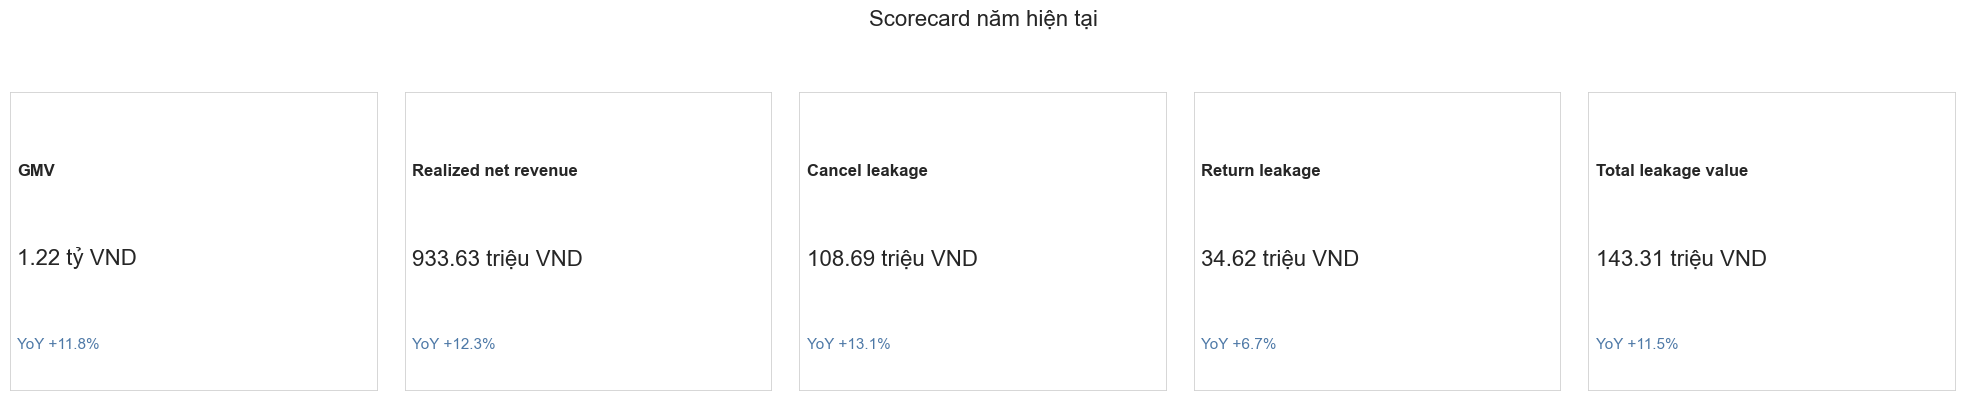

KPI theo quý (8 quý gần nhất)


,quarter,gmv,realized_net_revenue,resolved_orders,in_flight_orders,leakage_orders,return_orders,cancelled_orders,total_discount,cancel_leakage,return_leakage,aov,return_rate,cancel_rate,leakage_rate
34,2021-01-01,"234,136,908.5500","178,250,926.4500",6788,566,1107,401,706,"8,312,168.9300","22,257,361.5800","6,982,742.7200","26,259.7122",0.0591,0.1040,0.1631
35,2021-04-01,"418,488,600.1400","325,299,581.8600",11584,992,1784,702,1082,"12,131,441.4800","35,762,527.7100","12,871,479.1200","28,081.8009",0.0606,0.0934,0.1540
36,2021-07-01,"261,471,765.0800","194,512,768.8900",8239,709,1326,486,840,"17,348,385.7000","22,938,041.5200","7,189,262.9200","23,608.7837",0.0590,0.1020,0.1609
37,2021-10-01,"180,768,191.7700","133,063,280.9500",5197,450,850,329,521,"14,033,649.8000","15,139,598.3700","5,410,100.6400","25,603.8640",0.0633,0.1003,0.1636
38,2022-01-01,"285,182,898.2800","222,093,844.9800",7476,656,1172,434,738,"8,878,367.1800","24,631,265.6000","7,730,933.7700","29,707.5769",0.0581,0.0987,0.1568
39,2022-04-01,"429,252,589.3000","332,992,240.9400",11607,1026,1892,676,1216,"13,106,766.6400","38,763,783.6600","11,767,878.5000","28,688.9154",0.0582,0.1048,0.1630
40,2022-07-01,"315,702,433.5400","236,466,668.1600",8321,718,1397,561,836,"18,253,425.7600","27,307,977.9700","10,549,913.1200","28,418.0589",0.0674,0.1005,0.1679
41,2022-10-01,"194,052,645.7600","142,074,811.5900",5690,510,945,351,594,"14,203,175.6100","17,983,839.3400","4,572,590.1300","24,969.2112",0.0617,0.1044,0.1661


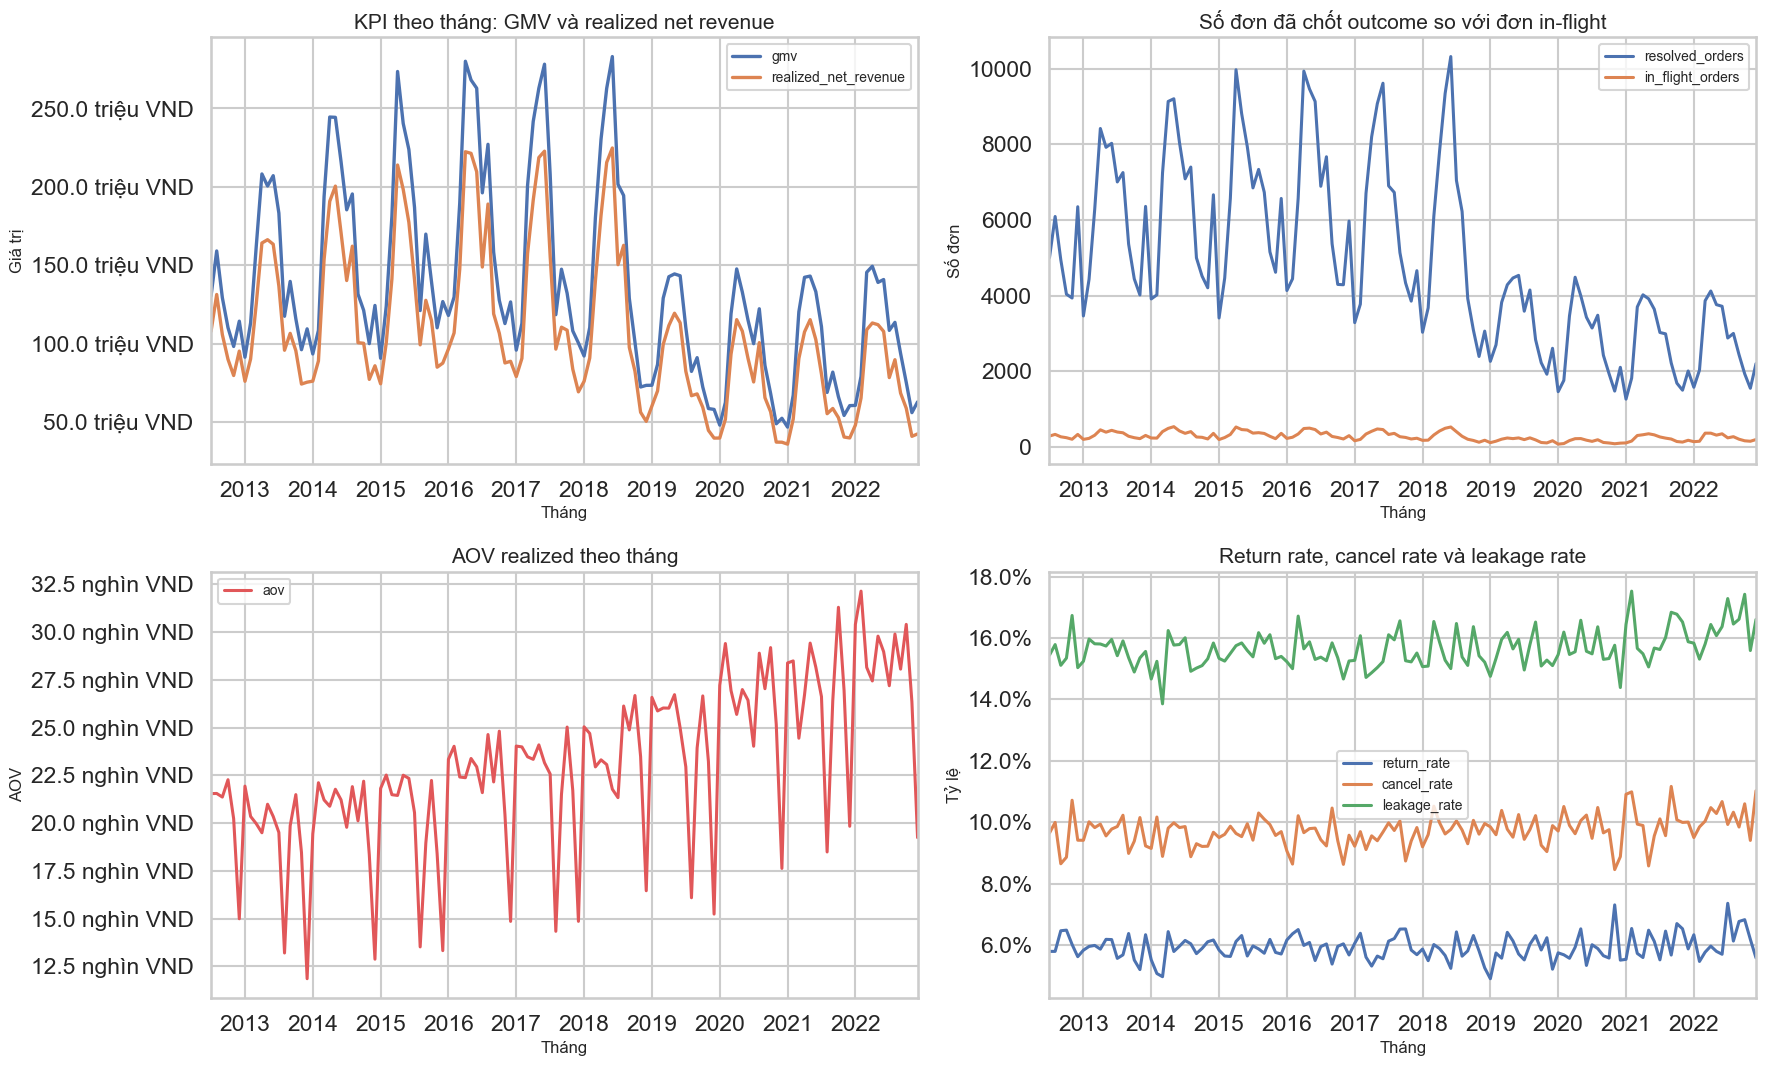

In [5]:
monthly_kpis = build_monthly_kpis(fact_order)
quarterly_kpis = build_quarterly_kpis(monthly_kpis)
geo_snapshot = build_geography_snapshot(fact_order)
recon_df = reconcile_with_sales(monthly_kpis, raw["sales"])
scorecard = build_descriptive_scorecard(fact_order, recent_year=recent_year)

display(scorecard)
plot_descriptive_scorecard(scorecard)

print("KPI theo quý (8 quý gần nhất)")
display(quarterly_kpis.tail(8))
plot_kpi_trends(monthly_kpis)


### 3.1 Seasonal Decomposition (Predictive Bridge)

Phần này được dùng để nhìn **trend + seasonality** của revenue theo tháng, nhằm hỗ trợ predictive framing. Nó không được dùng để kết luận root cause vận hành.


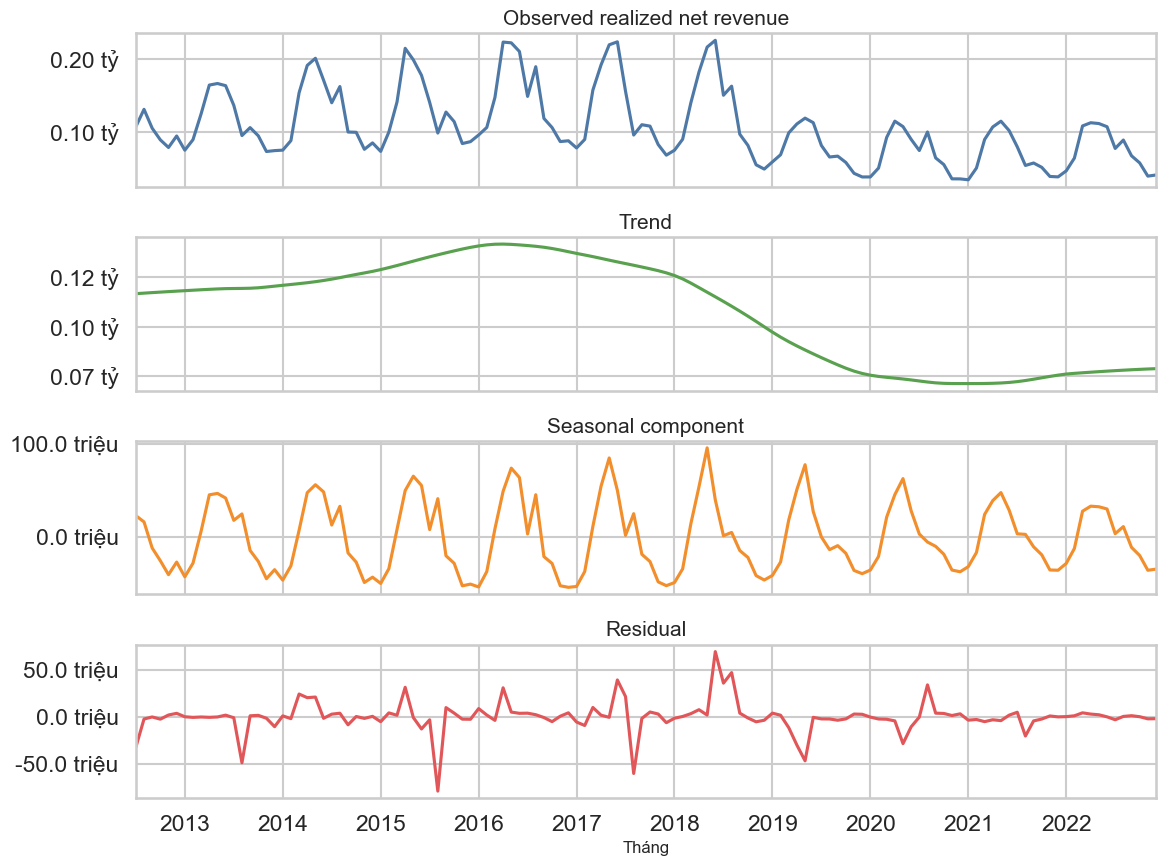

,month,seasonal_index
4,5,"64,671,994.0510"
3,4,"47,235,336.3003"
5,6,"41,711,229.7738"
7,8,"17,161,556.5305"


**Seasonality bridge:** mô hình STL cho thấy `May` là tháng có seasonal uplift mạnh nhất; vì vậy phần predictive nên ưu tiên tách tín hiệu seasonality khỏi tín hiệu rủi ro vận hành.

In [6]:
monthly_ts = monthly_kpis.set_index("order_month")["realized_net_revenue"].sort_index()
monthly_ts = monthly_ts.asfreq("MS")
monthly_ts = monthly_ts.interpolate(limit_direction="both")

if monthly_ts.notna().sum() >= 24:
    seasonal_method = "fallback"
    observed = monthly_ts.copy()

    try:
        from statsmodels.tsa.seasonal import STL

        stl = STL(monthly_ts, period=12, robust=True)
        stl_result = stl.fit()
        trend = pd.Series(stl_result.trend, index=monthly_ts.index)
        seasonal = pd.Series(stl_result.seasonal, index=monthly_ts.index)
        resid = pd.Series(stl_result.resid, index=monthly_ts.index)
        seasonal_method = "STL"
    except Exception:
        trend = monthly_ts.rolling(window=12, center=True, min_periods=6).mean()
        trend = trend.interpolate(limit_direction="both")
        detrended = monthly_ts - trend
        month_lookup = detrended.groupby(detrended.index.month).mean()
        seasonal = pd.Series(detrended.index.month, index=monthly_ts.index).map(month_lookup).astype(float)
        resid = monthly_ts - trend - seasonal

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    observed.plot(ax=axes[0], color="#4E79A7", title="Observed realized net revenue")
    trend.plot(
        ax=axes[1],
        color="#59A14F",
        title="Trend" if seasonal_method == "STL" else "Trend (12M rolling mean fallback)",
    )
    seasonal.plot(
        ax=axes[2],
        color="#F28E2B",
        title="Seasonal component" if seasonal_method == "STL" else "Seasonal index (month-of-year fallback)",
    )
    resid.plot(
        ax=axes[3],
        color="#E15759",
        title="Residual" if seasonal_method == "STL" else "Residual (after fallback decomposition)",
    )

    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e9:.2f} tỷ"))
    axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e9:.2f} tỷ"))
    axes[2].yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e6:.1f} triệu"))
    axes[3].yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e6:.1f} triệu"))
    axes[3].set_xlabel("Tháng")

    plt.tight_layout()
    plt.show()

    seasonal_rank = (
        pd.Series(seasonal.values, index=monthly_ts.index)
        .groupby(monthly_ts.index.month)
        .mean()
        .rename("seasonal_index")
        .reset_index()
        .rename(columns={"index": "month", "order_month": "month"})
        .sort_values("seasonal_index", ascending=False)
    )
    seasonal_rank["month"] = seasonal_rank["month"].astype(int)
    display(seasonal_rank.head(4))

    top_month = int(seasonal_rank.iloc[0]["month"])
    top_month_name = pd.Timestamp(year=recent_year, month=top_month, day=1).strftime("%B")
    method_note = (
        "mô hình STL"
        if seasonal_method == "STL"
        else "fallback decomposition bằng rolling trend + month-of-year index"
    )
    display(
        Markdown(
            f"**Seasonality bridge:** {method_note} cho thấy `{top_month_name}` là tháng có seasonal uplift mạnh nhất; "
            "vì vậy phần predictive nên ưu tiên tách tín hiệu seasonality khỏi tín hiệu rủi ro vận hành."
        )
    )
else:
    print("Chưa đủ độ dài chuỗi thời gian (>=24 tháng) để decomposition ổn định.")


,stage,value
0,GMV,"16,249,922,486.8400"
1,Discount,"-709,397,088.3100"
2,Cancel leakage,"-1,515,891,006.1900"
3,Return leakage,"-510,660,319.5900"
4,Realized net revenue,"13,513,974,072.7500"


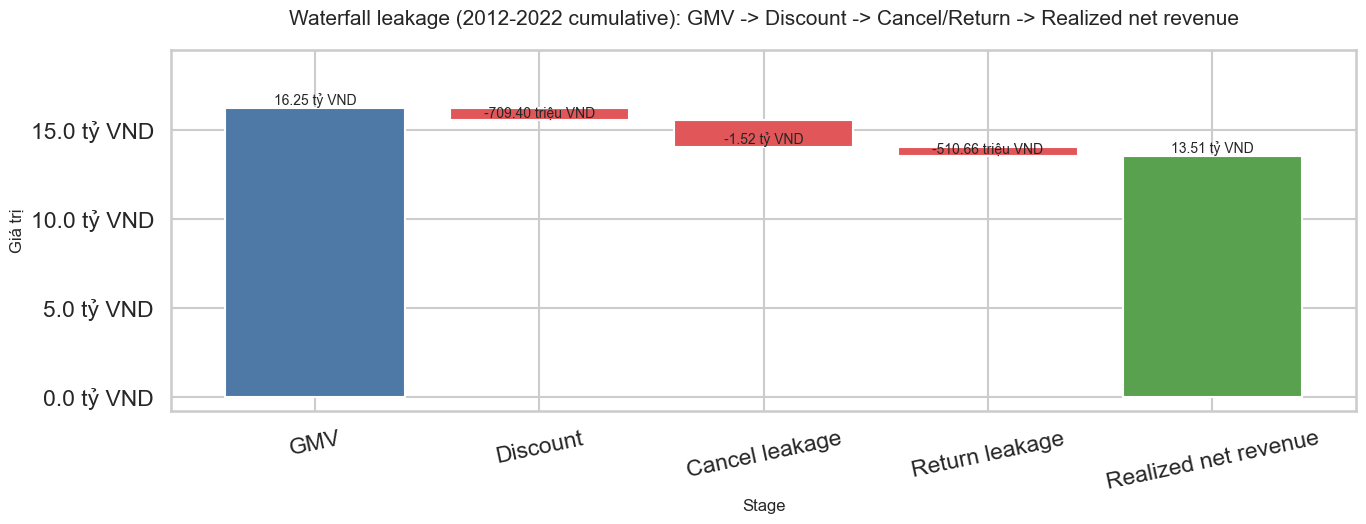

Đối soát revenue với bảng sales (12 tháng cuối)


,order_month,gmv,realized_net_revenue,resolved_orders,in_flight_orders,leakage_orders,return_orders,cancelled_orders,total_discount,cancel_leakage,return_leakage,aov,return_rate,cancel_rate,leakage_rate,quarter,sales_revenue,gap_vs_sales,alignment_ratio
114,2022-01-01,"60,595,626.7500","47,998,346.1800",1579,140,250,100,150,"932,140.4300","5,351,290.0000","1,669,121.2000","30,397.9393",0.0633,0.0950,0.1583,2022-01-01,"59,663,486.3200","11,665,140.1400",0.8045
115,2022-02-01,"79,103,095.5000","65,272,804.7900",2031,151,311,111,200,0.0000,"6,781,884.3000","2,219,769.5700","32,138.2594",0.0547,0.0985,0.1531,2022-01-01,"79,103,095.5000","13,830,290.7100",0.8252
116,2022-03-01,"145,484,176.0300","108,822,694.0100",3866,365,611,223,388,"7,946,226.7500","12,498,091.3000","3,842,043.0000","28,148.6534",0.0577,0.1004,0.1580,2022-01-01,"137,537,949.2800","28,715,255.2700",0.7912
117,2022-04-01,"149,356,522.8300","113,154,675.5600",4124,365,678,246,432,"8,051,014.0200","12,737,785.7700","4,094,854.0800","27,438.0882",0.0597,0.1048,0.1644,2022-04-01,"141,305,508.8100","28,150,833.2500",0.8008
118,2022-05-01,"139,027,887.1600","112,074,196.4300",3763,313,605,218,387,0.0000,"13,181,767.4700","3,941,123.4400","29,783.2039",0.0579,0.1028,0.1608,2022-04-01,"139,027,887.1600","26,953,690.7300",0.8061
119,2022-06-01,"140,868,179.3100","107,763,368.9500",3720,348,609,212,397,"5,055,752.6200","12,844,230.4200","3,731,900.9800","28,968.6476",0.0570,0.1067,0.1637,2022-04-01,"135,812,426.6900","28,049,057.7400",0.7935
120,2022-07-01,"108,440,836.8800","78,328,536.7900",2881,241,498,212,286,"10,299,059.1600","8,483,730.9800","4,143,248.4500","27,187.9683",0.0736,0.0993,0.1729,2022-07-01,"98,141,777.7200","19,813,240.9300",0.7981
121,2022-08-01,"113,549,880.0300","89,736,375.9500",3002,272,494,184,310,"6,936.5600","11,081,313.7500","3,440,427.7600","29,892.1972",0.0613,0.1033,0.1646,2022-07-01,"113,542,943.4700","23,806,567.5200",0.7903
122,2022-09-01,"93,711,716.6300","68,401,755.4200",2438,205,405,165,240,"7,947,430.0400","7,742,933.2400","2,966,236.9100","28,056.5035",0.0677,0.0984,0.1661,2022-07-01,"85,764,286.5900","17,362,531.1700",0.7976
123,2022-10-01,"75,251,885.5400","58,790,348.3100",1934,163,337,132,205,"57,433.2300","7,929,964.4700","2,515,900.0200","30,398.3187",0.0683,0.1060,0.1743,2022-10-01,"75,194,452.3100","16,404,104.0000",0.7818


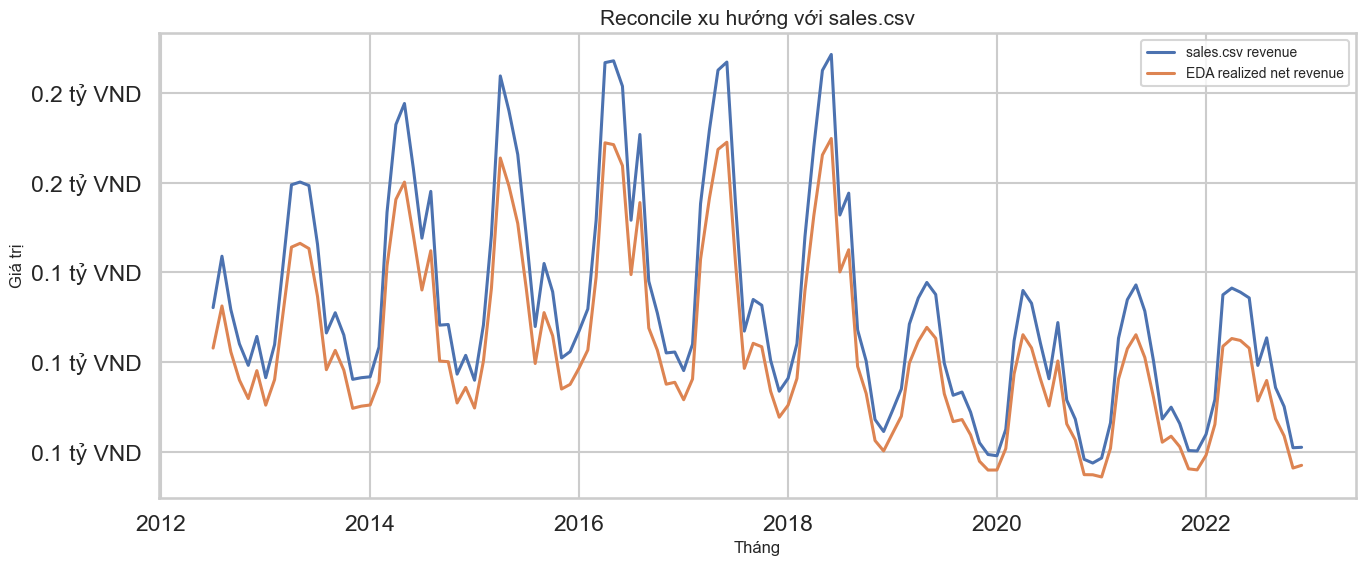

In [7]:
waterfall_df = build_waterfall_summary(fact_order)
display(waterfall_df)
plot_waterfall(waterfall_df)

print("Đối soát revenue với bảng sales (12 tháng cuối)")
display(recon_df.tail(12))
plot_sales_reconciliation(recon_df)


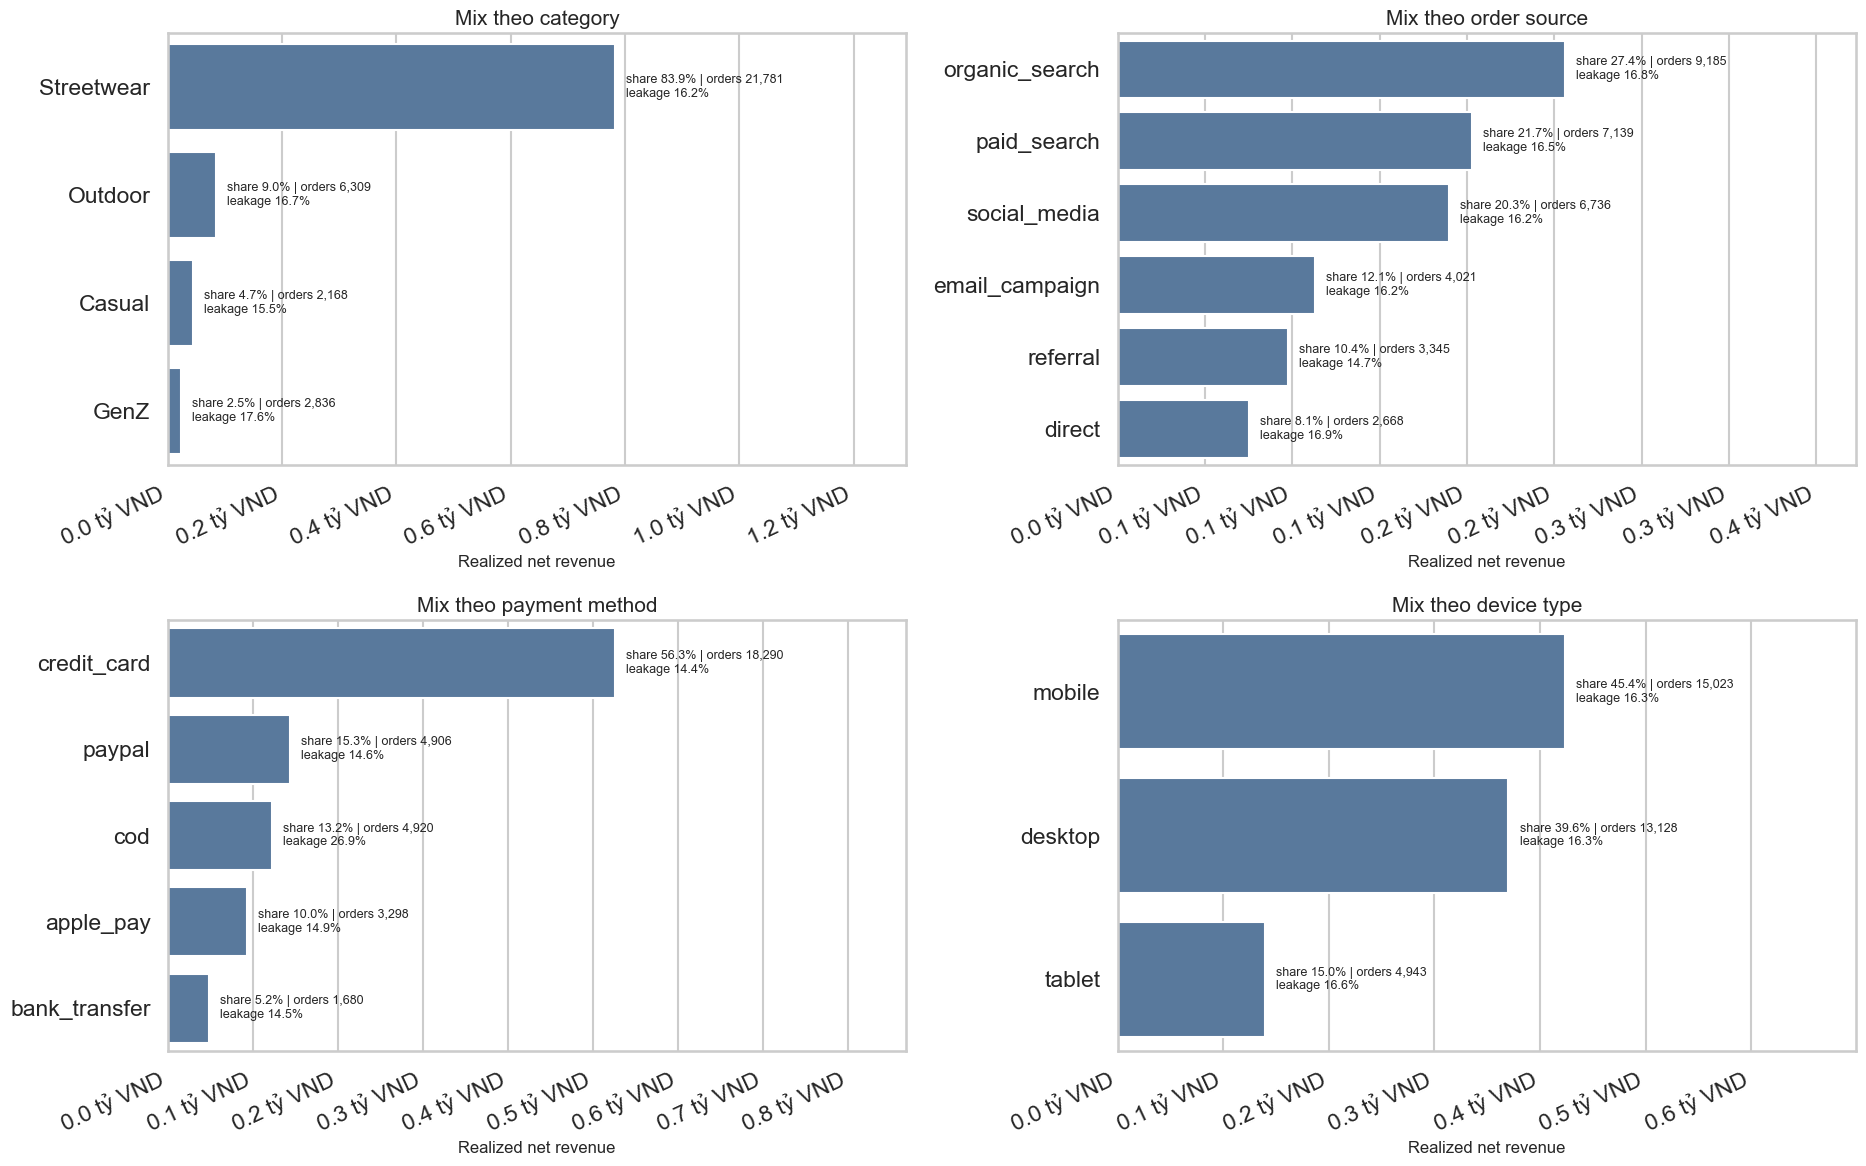

,region,realized_net_revenue,resolved_orders,return_orders,cancelled_orders,avg_delivery_days,return_rate,cancel_rate
1,East,"435,267,584.5600",15203,926,1584,4.5139,0.0609,0.1042
0,Central,"306,961,865.9700",10318,649,1055,4.5115,0.0629,0.1022
2,West,"191,398,115.1400",7573,447,745,4.5055,0.0590,0.0984


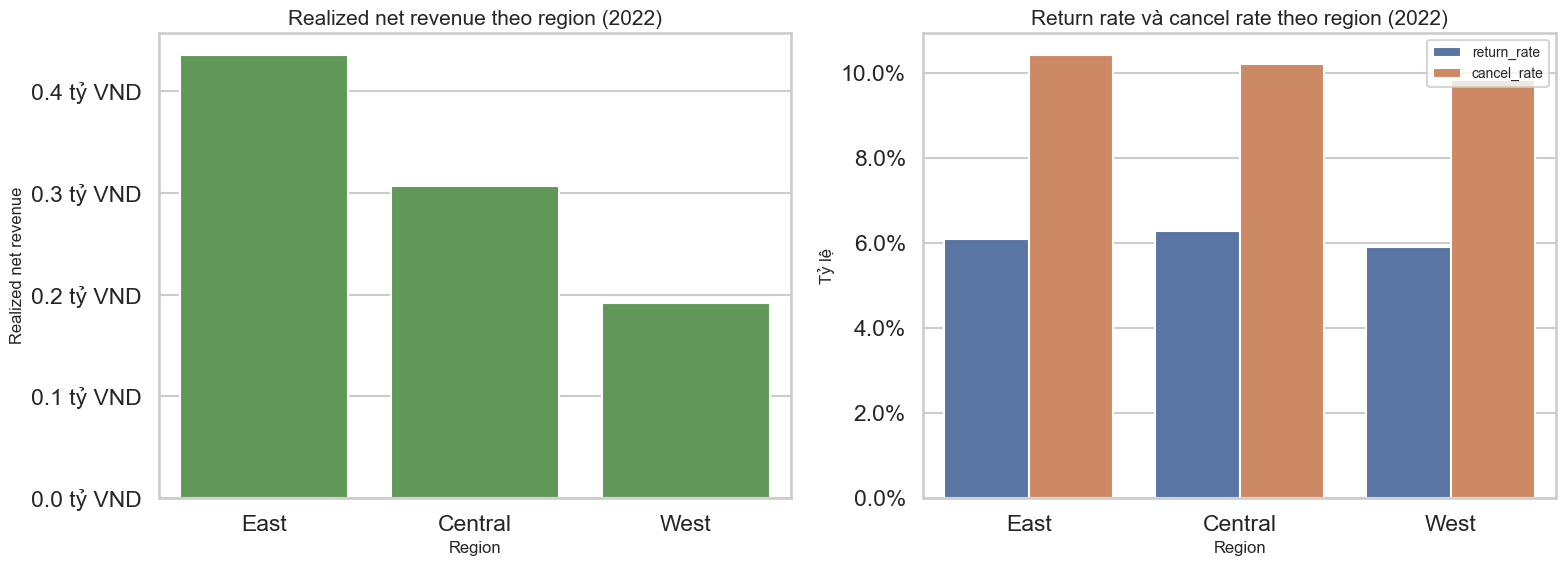

In [8]:
plot_mix_dashboard(fact_order, recent_year=recent_year)
display(geo_snapshot)
plot_geography_snapshot(geo_snapshot)


In [9]:
descriptive_points = build_descriptive_summary(monthly_kpis, fact_order, geo_snapshot)
descriptive_md = "## Descriptive takeaways\n" + "\n".join([f"- {point}" for point in descriptive_points])
display(Markdown(descriptive_md))


## Descriptive takeaways
- Năm 2022, realized net revenue đạt 933.63 triệu VND, thay đổi +12.3% YoY; tổng leakage value đạt 143.31 triệu VND (+11.5% YoY).
- Tháng mạnh nhất trong năm là 04/2022 với 113.15 triệu VND realized net revenue, trong khi tháng áp lực leakage cao nhất là 10/2022 ở mức 17.4%.
- Streetwear dẫn dắt 83.9% realized net revenue và 65.8% volume resolved của năm 2022; East đóng góp 46.6% realized net revenue, trong khi 91.9% flow của năm đã chốt outcome.

### 3.2 Web Traffic Bridge (Leading Indicator)

Web traffic được dùng như **leading indicator** để nối hành vi demand với doanh thu thực nhận. Phần này tăng chiều sâu storytelling, nhưng không được dùng để đẩy action nếu không có bằng chứng diagnostic đi kèm.


,gmv,realized_net_revenue,sessions,unique_visitors,avg_bounce,avg_session_duration_sec,avg_pages_per_session
gmv,1.0000,0.9952,0.4474,0.4470,-0.1050,-0.1533,0.0274
realized_net_revenue,0.9952,1.0000,0.4445,0.4444,-0.1029,-0.1489,0.0237
sessions,0.4474,0.4445,1.0000,0.9998,-0.0350,-0.1252,0.0624
unique_visitors,0.4470,0.4444,0.9998,1.0000,-0.0364,-0.1297,0.0642
avg_bounce,-0.1050,-0.1029,-0.0350,-0.0364,1.0000,-0.0575,-0.1074
avg_session_duration_sec,-0.1533,-0.1489,-0.1252,-0.1297,-0.0575,1.0000,0.0002
avg_pages_per_session,0.0274,0.0237,0.0624,0.0642,-0.1074,0.0002,1.0000


,traffic_source,total_sessions,avg_bounce,avg_session_duration_sec,avg_pages_per_session
1,email_campaign,12792670,0.0045,213.2206,4.3207
5,social_media,15816226,0.0045,210.2902,4.3138
3,paid_search,19598271,0.0045,209.3621,4.3291
4,referral,9476845,0.0045,207.5587,4.3906
2,organic_search,27196976,0.0045,211.1539,4.3237
0,direct,6571549,0.0045,207.6782,4.4136


,lag_days,corr_sessions_to_revenue
0,1,0.3112
1,7,0.2996
2,14,0.2790
3,30,0.2048


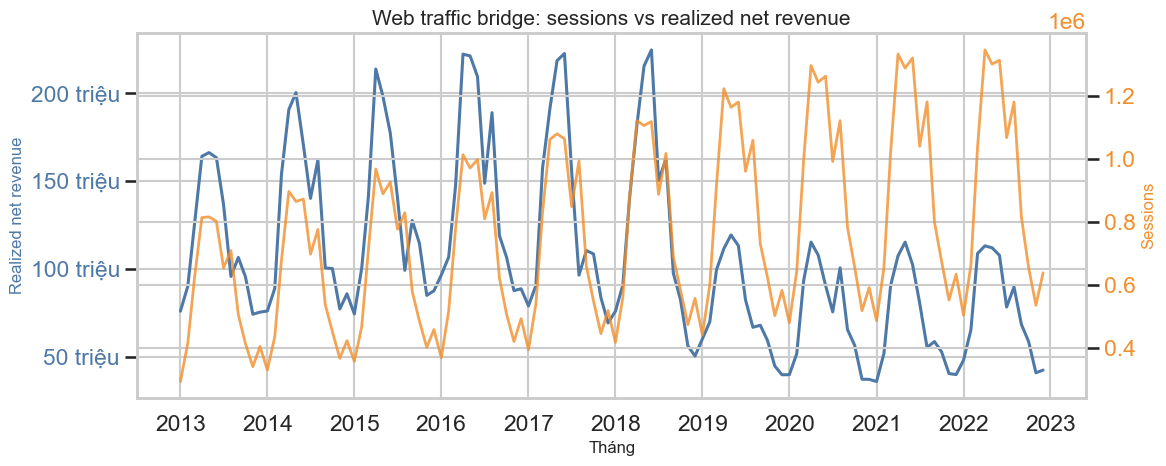

## Traffic bridge takeaways
- Sessions có tương quan `0.44` với realized net revenue ở cấp tháng; đây là leading indicator hữu ích cho demand monitoring.
- Lag hiệu quả nhất trong phép thử đơn giản là `1` ngày với tương quan `0.31`.
- `email_campaign` là nguồn có bounce thấp nhất trong nhóm top source, nên phù hợp làm benchmark cho quality traffic.
- Phần này được giữ như cầu nối descriptive -> predictive, không dùng làm action core nếu thiếu diagnostic trực tiếp.

In [10]:
traffic = raw["web_traffic"].copy()
traffic["date"] = pd.to_datetime(traffic["date"])
traffic["order_month"] = traffic["date"].dt.to_period("M").dt.to_timestamp()
traffic["pages_per_session"] = traffic["page_views"] / traffic["sessions"].replace(0, np.nan)

traffic_monthly = (
    traffic.groupby("order_month", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        avg_bounce=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
        avg_pages_per_session=("pages_per_session", "mean"),
    )
)

traffic_kpi = monthly_kpis.merge(traffic_monthly, on="order_month", how="left")
corr_cols = [
    "gmv",
    "realized_net_revenue",
    "sessions",
    "unique_visitors",
    "avg_bounce",
    "avg_session_duration_sec",
    "avg_pages_per_session",
]
corr_table = traffic_kpi[corr_cols].corr()
display(corr_table)

source_perf = (
    traffic.groupby("traffic_source", as_index=False)
    .agg(
        total_sessions=("sessions", "sum"),
        avg_bounce=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
        avg_pages_per_session=("pages_per_session", "mean"),
    )
    .sort_values(["avg_bounce", "avg_session_duration_sec"], ascending=[True, False])
)
display(source_perf.head(8))

lag_rows = []
daily_revenue = (
    fact_order.groupby("order_date", as_index=False)["realized_net_revenue"]
    .sum()
    .rename(columns={"order_date": "date"})
)
traffic_daily = traffic.groupby("date", as_index=False)["sessions"].sum()
for lag in [1, 7, 14, 30]:
    shifted = traffic_daily.copy()
    shifted["date"] = shifted["date"] + pd.Timedelta(days=lag)
    joined = daily_revenue.merge(shifted, on="date", how="inner")
    corr_val = joined["realized_net_revenue"].corr(joined["sessions"])
    lag_rows.append({"lag_days": lag, "corr_sessions_to_revenue": corr_val})
lag_corr_df = pd.DataFrame(lag_rows).sort_values("corr_sessions_to_revenue", ascending=False)
display(lag_corr_df)

bridge_plot = traffic_kpi[["order_month", "realized_net_revenue", "sessions"]].dropna().copy()
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(
    bridge_plot["order_month"],
    bridge_plot["realized_net_revenue"],
    color="#4E79A7",
    linewidth=2.2,
    label="Realized net revenue",
)
ax1.set_ylabel("Realized net revenue", color="#4E79A7")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e6:.0f} triệu"))
ax1.tick_params(axis="y", labelcolor="#4E79A7")

ax2 = ax1.twinx()
ax2.plot(
    bridge_plot["order_month"],
    bridge_plot["sessions"],
    color="#F28E2B",
    linewidth=2,
    alpha=0.8,
    label="Sessions",
)
ax2.set_ylabel("Sessions", color="#F28E2B")
ax2.tick_params(axis="y", labelcolor="#F28E2B")
ax1.set_title("Web traffic bridge: sessions vs realized net revenue")
ax1.set_xlabel("Tháng")
plt.tight_layout()
plt.show()

best_lag = lag_corr_df.iloc[0]
best_source = source_perf.iloc[0]
sessions_corr = corr_table.loc["realized_net_revenue", "sessions"]
display(
    Markdown(
        "## Traffic bridge takeaways\n"
        f"- Sessions có tương quan `{sessions_corr:.2f}` với realized net revenue ở cấp tháng; đây là leading indicator hữu ích cho demand monitoring.\n"
        f"- Lag hiệu quả nhất trong phép thử đơn giản là `{int(best_lag['lag_days'])}` ngày với tương quan `{best_lag['corr_sessions_to_revenue']:.2f}`.\n"
        f"- `{best_source['traffic_source']}` là nguồn có bounce thấp nhất trong nhóm top source, nên phù hợp làm benchmark cho quality traffic.\n"
        "- Phần này được giữ như cầu nối descriptive -> predictive, không dùng làm action core nếu thiếu diagnostic trực tiếp."
    )
)


## 4. Diagnostic Analysis - Why Did It Happen?

Main story chỉ giữ các driver đủ mạnh để ra quyết định: `payment friction`, `wrong-size return`, `promotion erosion (proxy)`. Những tín hiệu yếu hơn được để ở mức caveat thay vì đẩy thành root cause.


,metric,value,note
0,Overall cancel rate,0.0971,Tỷ lệ hủy trên toàn bộ resolved orders
1,cod cancel rate,0.1692,Lift 1.74x so với baseline
2,cod vs non-cod gap,0.0847,"Bootstrap CI [8.2%, 8.7%]"
3,cod share of cancel leakage,0.2600,"Scope 91,443 orders"


,payment_method,orders,cancelled_orders,cancel_leakage_value,scope_value,avg_order_value,cancel_rate,rate_lift_vs_avg,share_of_cancel_leakage,priority_score
0,cod,91443,15468,"394,200,161.6100","2,322,894,981.6200","25,402.6550",0.1692,1.7419,0.2600,"686,656,330.0666"
1,credit_card,337332,28452,"726,926,951.6200","8,551,779,896.0600","25,351.2264",0.0843,0.8685,0.4795,"631,371,482.8589"
2,paypal,91847,7817,"199,499,370.8000","2,345,999,928.9900","25,542.4775",0.0851,0.8764,0.1316,"174,845,958.8445"
3,apple_pay,61295,5190,"130,729,151.3900","1,550,864,341.6200","25,301.6452",0.0847,0.8719,0.0862,"113,986,569.3211"
4,bank_transfer,30403,2535,"64,535,370.7700","768,986,250.2400","25,293.1043",0.0834,0.8586,0.0426,"55,411,290.6553"


,payment_method,order_source,orders,cancelled_orders,cancel_leakage_value,scope_value,cancel_rate,method_cancel_rate,rate_gap_vs_method,share_of_method_orders
0,credit_card,organic_search,94664,8016,"205,714,252.1400","2,396,609,182.2400",0.0847,0.0843,0.0003,0.2806
1,credit_card,paid_search,73595,6161,"156,136,498.9900","1,867,194,694.6600",0.0837,0.0843,-0.0006,0.2182
2,credit_card,social_media,67517,5719,"148,479,318.4100","1,711,763,503.5700",0.0847,0.0843,0.0004,0.2002
3,cod,organic_search,25431,4334,"109,393,160.8400","646,669,992.6100",0.1704,0.1692,0.0013,0.2781
4,cod,paid_search,20100,3377,"87,985,528.5000","512,057,251.9400",0.1680,0.1692,-0.0011,0.2198
5,credit_card,email_campaign,40644,3391,"85,965,244.7500","1,031,862,584.5800",0.0834,0.0843,-0.0009,0.1205
6,cod,social_media,18530,3037,"75,997,758.0100","468,166,307.1200",0.1639,0.1692,-0.0053,0.2026
7,credit_card,referral,33909,2901,"72,440,847.7800","857,944,163.4500",0.0856,0.0843,0.0012,0.1005


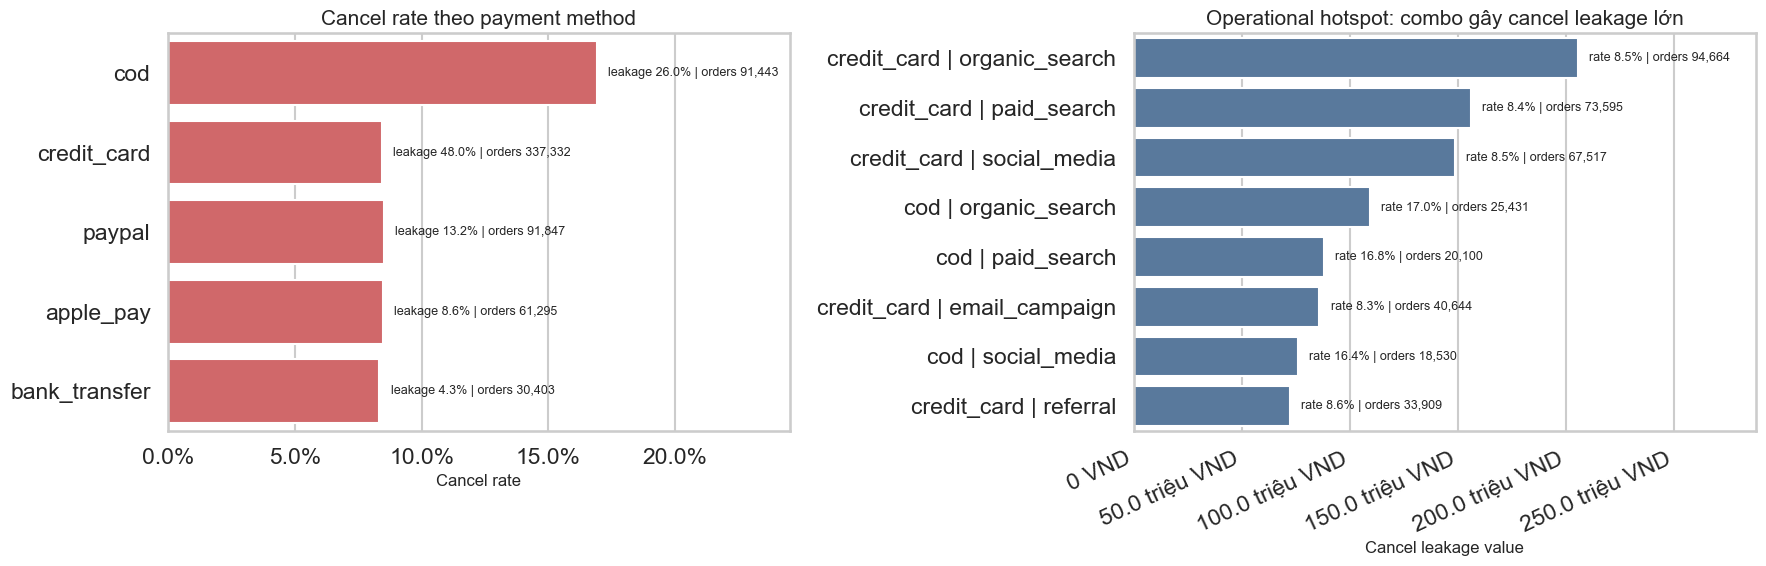

## Diagnostic 1 - Cancellation friction
- Trên **full-history resolved sample**, `COD` có cancel rate `16.9%`, cao hơn baseline `1.74x` và chiếm `26.0%` cancel leakage.
- Hotspot vận hành nên theo dõi trước là `cod x organic_search` vì bucket này đang giữ `25,431` orders và `109.4` triệu VND leakage.
- Hàm ý hành động: ưu tiên giảm friction ở checkout và CRM cho payment method rủi ro cao; phần prescriptive phía dưới sẽ size upside trên scope năm `2022` để tránh phóng đại benefit.

In [11]:
cancel_methods, cancel_combos, cancel_metrics = build_cancellation_story(fact_order)
display(cancel_metrics)
display(cancel_methods.head(8))
display(cancel_combos.head(8))
plot_cancellation_story(cancel_methods, cancel_combos)

top_cancel = cancel_methods.iloc[0]
hotspot_combo = (
    cancel_combos.loc[cancel_combos["payment_method"].eq(top_cancel["payment_method"])]
    .sort_values("cancel_leakage_value", ascending=False)
    .iloc[0]
)
display(
    Markdown(
        "## Diagnostic 1 - Cancellation friction\n"
        f"- Trên **full-history resolved sample**, `{str(top_cancel['payment_method']).upper()}` có cancel rate `{top_cancel['cancel_rate']:.1%}`, cao hơn baseline `{top_cancel['rate_lift_vs_avg']:.2f}x` và chiếm `{top_cancel['share_of_cancel_leakage']:.1%}` cancel leakage.\n"
        f"- Hotspot vận hành nên theo dõi trước là `{hotspot_combo['payment_method']} x {hotspot_combo['order_source']}` vì bucket này đang giữ `{hotspot_combo['orders']:,}` orders và `{hotspot_combo['cancel_leakage_value']/1e6:.1f}` triệu VND leakage.\n"
        f"- Hàm ý hành động: ưu tiên giảm friction ở checkout và CRM cho payment method rủi ro cao; phần prescriptive phía dưới sẽ size upside trên scope năm `{recent_year}` để tránh phóng đại benefit."
    )
)


,category,size,order_lines,wrong_size_returns,wrong_size_refund_value,wrong_size_rate,share_of_wrong_size_refund,bucket
0,Streetwear,XL,121243,2319,"47,191,819.3700",0.0191,0.2670,Streetwear | size XL
1,Streetwear,S,95073,1858,"32,449,294.5100",0.0195,0.1836,Streetwear | size S
2,Streetwear,M,87602,1730,"30,620,865.7400",0.0197,0.1732,Streetwear | size M
3,Streetwear,L,88598,1719,"30,149,470.2500",0.0194,0.1706,Streetwear | size L
4,Outdoor,L,71868,1457,"7,348,076.3900",0.0203,0.0416,Outdoor | size L
5,Outdoor,M,70743,1383,"7,295,363.9500",0.0195,0.0413,Outdoor | size M
6,Outdoor,XL,61233,1190,"6,550,242.0600",0.0194,0.0371,Outdoor | size XL
7,Outdoor,S,55475,1124,"6,162,237.6900",0.0203,0.0349,Outdoor | size S
8,Casual,S,8217,157,"1,713,040.6400",0.0191,0.0097,Casual | size S
9,GenZ,M,10266,226,"1,404,316.4900",0.0220,0.0079,GenZ | size M


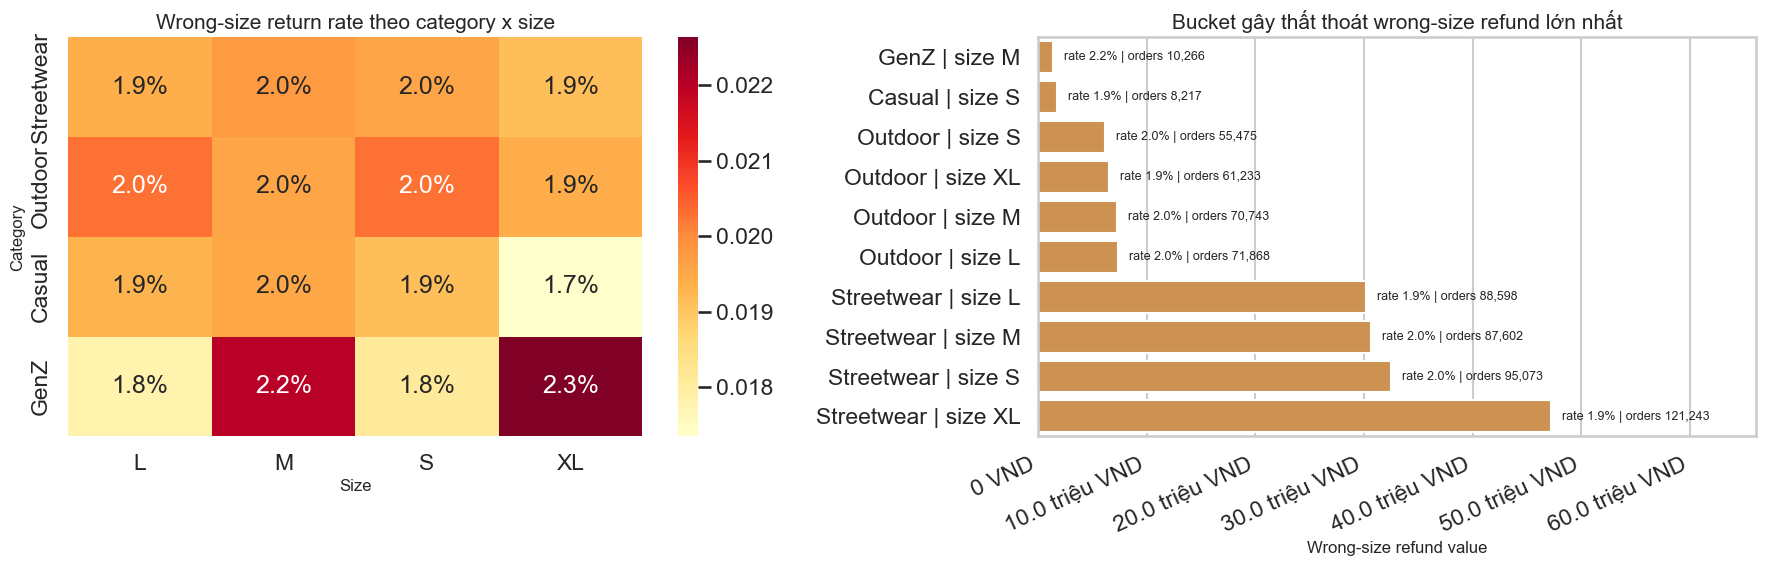

## Diagnostic 2 - Wrong-size return
- Trên **full-history order-line sample**, bucket nặng nhất là `Streetwear | size XL` với wrong-size rate `1.9%` trên `121,243` order lines.
- Bucket này một mình chiếm `26.7%` wrong-size refund value, tương đương `47.2` triệu VND.
- Hàm ý hành động: ưu tiên fit guide, exchange-first flow và content sizing cho bucket lớn trước; phần action phía dưới chỉ size impact trên scope năm `2022`.

In [12]:
size_pivot, size_ranking = build_size_story(fact_line)
display(size_ranking.head(12))
plot_size_story(size_pivot, size_ranking)

top_size = size_ranking.iloc[0]
display(
    Markdown(
        "## Diagnostic 2 - Wrong-size return\n"
        f"- Trên **full-history order-line sample**, bucket nặng nhất là `{top_size['bucket']}` với wrong-size rate `{top_size['wrong_size_rate']:.1%}` trên `{int(top_size['order_lines']):,}` order lines.\n"
        f"- Bucket này một mình chiếm `{top_size['share_of_wrong_size_refund']:.1%}` wrong-size refund value, tương đương `{top_size['wrong_size_refund_value']/1e6:.1f}` triệu VND.\n"
        f"- Hàm ý hành động: ưu tiên fit guide, exchange-first flow và content sizing cho bucket lớn trước; phần action phía dưới chỉ size impact trên scope năm `{recent_year}`."
    )
)


,dominant_category,order_source,months_observed,paired_months,promo_orders,control_orders,negative_margin_months,negative_month_share,avg_discount_rate_promo,median_margin_delta,weighted_margin_delta,weighted_net_delta,weighted_leakage_delta,erosion_value_proxy,recent_year,recent_year_months,recent_year_promo_orders,recent_year_control_orders,recent_year_negative_margin_months,recent_year_negative_share,recent_year_weighted_margin_delta,recent_year_erosion_value_proxy,is_core_story
0,Streetwear,organic_search,63,63,28251,30318,63,1.0000,0.1158,"-5,802.0918","-5,890.2236","-5,311.8380",-0.0050,"166,404,708.3029",2022,7,1890,1896,7,1.0000,"-7,099.8377","13,418,693.2031",True
1,Streetwear,paid_search,59,59,22056,22510,59,1.0000,0.1152,"-5,861.6465","-5,807.2480","-5,405.1782",0.0016,"128,084,661.8435",2022,6,1393,1306,6,1.0000,"-5,616.0495","7,823,156.9171",True
2,Streetwear,social_media,57,57,19585,20382,57,1.0000,0.1157,"-5,955.9166","-5,933.3914","-5,749.7578",0.0042,"116,205,470.4576",2022,5,1024,1227,5,1.0000,"-6,457.8222","6,612,809.9771",True
3,Streetwear,referral,51,51,8346,9715,51,1.0000,0.1283,"-5,929.6851","-5,510.6274","-5,240.9698",0.0061,"45,991,696.3608",2022,5,524,602,5,1.0000,"-7,784.5165","4,079,086.6411",True
4,Streetwear,email_campaign,54,54,10901,12107,54,1.0000,0.1222,"-5,467.7446","-5,524.2232","-5,324.6294",-0.0020,"60,219,557.5409",2022,5,644,708,5,1.0000,"-5,810.1677","3,741,748.0228",True
5,Streetwear,direct,49,49,6535,7691,49,1.0000,0.1291,"-5,640.4363","-5,539.7300","-4,736.2740",-0.0012,"36,202,135.6602",2022,5,413,429,5,1.0000,"-6,414.5811","2,649,221.9746",True
6,Outdoor,organic_search,61,61,12166,13569,61,1.0000,0.1259,"-2,131.4820","-1,947.0797","-1,985.4164",-0.0006,"23,688,171.1471",2022,5,377,389,5,1.0000,"-2,067.4003","779,409.9286",True
7,Outdoor,social_media,55,55,8107,8796,55,1.0000,0.1279,"-2,198.4564","-2,081.5097","-2,200.0534",0.0029,"16,874,799.0010",2022,5,260,295,5,1.0000,"-2,616.2144","680,215.7490",True
8,Outdoor,paid_search,57,57,9236,9804,57,1.0000,0.1258,"-1,853.0562","-1,919.8659","-1,972.8388",-0.0115,"17,731,881.0481",2022,4,233,227,4,1.0000,"-1,990.3912","463,761.1490",True
9,Outdoor,email_campaign,44,44,4212,4705,44,1.0000,0.1304,"-2,255.9821","-2,156.5096","-2,666.6336",-0.0049,"9,083,218.5207",2022,3,116,114,3,1.0000,"-2,647.8527","307,150.9147",True


,order_month,dominant_category,order_source,avg_discount_rate_no_promo,avg_discount_rate_promo,avg_margin_no_promo,avg_margin_promo,avg_net_no_promo,avg_net_promo,leakage_rate_no_promo,leakage_rate_promo,orders_no_promo,orders_promo,net_delta,margin_delta,leakage_delta,bucket_weight
0,2013-08-01,Streetwear,paid_search,0.0000,0.0171,"6,474.5544","-11,304.2830","31,522.1446","15,030.8244",0.0811,0.1647,37.0000,911.0000,"-16,491.3202","-17,778.8374",0.0836,948.0000
1,2015-08-01,Streetwear,social_media,0.0000,0.0172,"5,999.8244","-11,111.3318","30,484.4746","14,917.0326",0.0714,0.1609,28.0000,839.0000,"-15,567.4420","-17,111.1562",0.0895,867.0000
2,2015-08-01,Streetwear,paid_search,0.0000,0.0178,"6,230.2870","-10,868.1368","26,427.7629","15,029.5037",0.0488,0.1681,41.0000,"1,017.0000","-11,398.2592","-17,098.4239",0.1194,"1,058.0000"
3,2013-08-01,Streetwear,organic_search,0.0000,0.0164,"6,425.8179","-10,665.4712","28,980.6237","14,733.2180",0.2321,0.1657,56.0000,"1,153.0000","-14,247.4058","-17,091.2891",-0.0665,"1,209.0000"
4,2013-08-01,Streetwear,social_media,0.0000,0.0169,"5,968.8282","-10,950.7843","36,728.6431","15,521.3422",0.0000,0.1566,35.0000,862.0000,"-21,207.3009","-16,919.6125",0.1566,897.0000
5,2013-08-01,Streetwear,email_campaign,0.0000,0.0178,"4,250.4735","-10,537.4003","26,101.8515","13,781.3981",0.1923,0.1520,26.0000,454.0000,"-12,320.4534","-14,787.8739",-0.0403,480.0000
6,2015-08-01,Streetwear,organic_search,0.0000,0.0169,"3,291.6220","-11,026.3482","28,369.7178","15,189.0532",0.2400,0.1597,50.0000,"1,221.0000","-13,180.6646","-14,317.9702",-0.0803,"1,271.0000"
7,2022-06-01,Streetwear,referral,0.0000,0.1525,"7,409.7300","-4,473.9569","39,917.4731","29,846.0646",0.1152,0.1731,217.0000,52.0000,"-10,071.4085","-11,883.6869",0.0579,269.0000
8,2018-01-01,Streetwear,organic_search,0.0000,0.1667,"6,166.0747","-5,631.3251","34,247.2836","26,839.2811",0.1369,0.1852,431.0000,27.0000,"-7,408.0025","-11,797.3998",0.0483,458.0000
9,2022-01-01,Streetwear,organic_search,0.0000,0.1667,"6,258.6618","-5,516.8457","39,655.1089","32,631.5742",0.1660,0.1923,247.0000,26.0000,"-7,023.5347","-11,775.5075",0.0263,273.0000


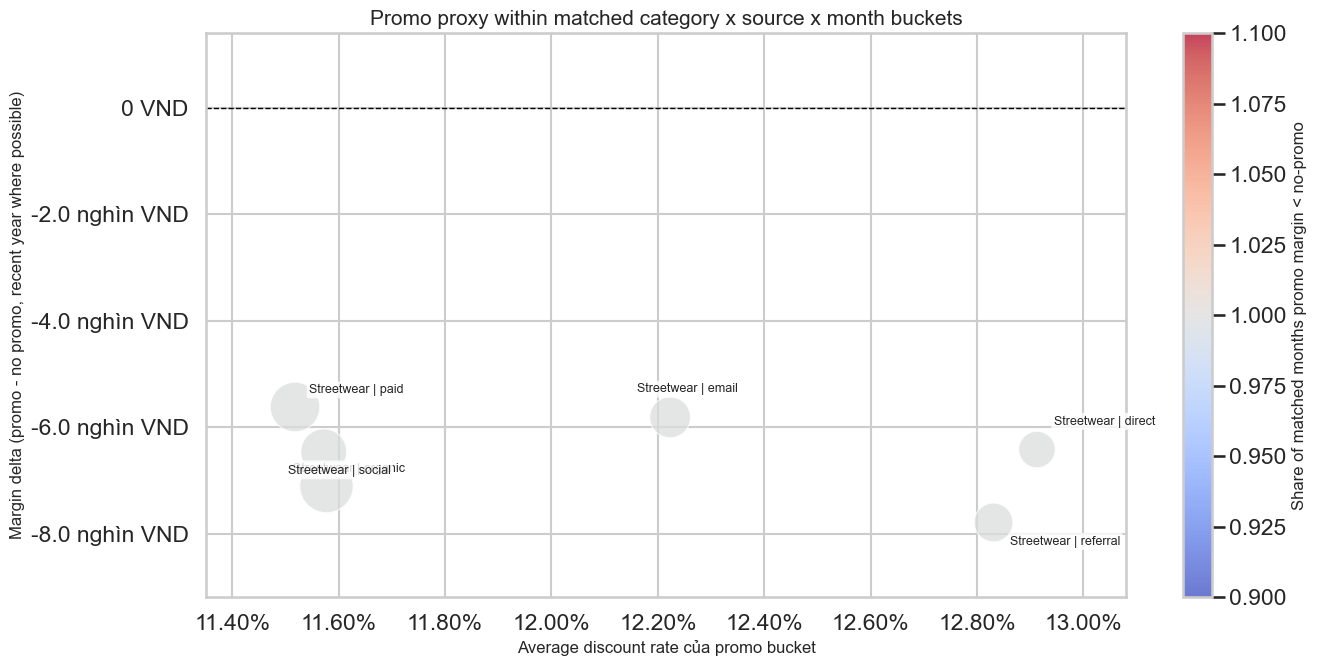

## Diagnostic 3 - Promotion erosion (proxy)
- Trong so sánh **matched theo tháng trong cùng `category x source`**, bucket rõ nhất là `Streetwear x organic_search` với margin delta `-7.1` nghìn VND ở scope năm `2022`.
- Bucket này có `1,890` promo orders ở năm `2022`; trên full history, tín hiệu âm lặp lại ở `100%` matched months và median margin delta vẫn âm `-5.8` nghìn VND.
- Hàm ý hành động: đây là **proxy signal đủ ổn định để pilot guardrail theo bucket**, nhưng không được diễn giải như causal proof để cắt promo diện rộng.

In [13]:
promo_summary, promo_monthly = build_promo_story(fact_order)
display(promo_summary.head(12))
display(promo_monthly.head(12))
plot_promo_story(promo_summary)

promo_core = promo_summary.loc[promo_summary["is_core_story"]].head(1)
if promo_core.empty:
    promo_core = promo_summary.head(1)
promo_core = promo_core.iloc[0]

promo_recent_margin = (
    promo_core["recent_year_weighted_margin_delta"]
    if pd.notna(promo_core.get("recent_year_weighted_margin_delta"))
    else promo_core["weighted_margin_delta"]
)
promo_recent_negative_share = (
    promo_core["recent_year_negative_share"]
    if pd.notna(promo_core.get("recent_year_negative_share"))
    else promo_core["negative_month_share"]
)
promo_recent_orders = int(
    promo_core["recent_year_promo_orders"] if promo_core.get("recent_year_promo_orders", 0) else promo_core["promo_orders"]
)
promo_recent_year = int(promo_core["recent_year"]) if pd.notna(promo_core.get("recent_year")) else recent_year

display(
    Markdown(
        "## Diagnostic 3 - Promotion erosion (proxy)\n"
        f"- Trong so sánh **matched theo tháng trong cùng `category x source`**, bucket rõ nhất là `{promo_core['dominant_category']} x {promo_core['order_source']}` với margin delta `{promo_recent_margin/1e3:.1f}` nghìn VND ở scope năm `{promo_recent_year}`.\n"
        f"- Bucket này có `{promo_recent_orders:,}` promo orders ở năm `{promo_recent_year}`; trên full history, tín hiệu âm lặp lại ở `{promo_core['negative_month_share']:.0%}` matched months và median margin delta vẫn âm `{promo_core['median_margin_delta']/1e3:.1f}` nghìn VND.\n"
        "- Hàm ý hành động: đây là **proxy signal đủ ổn định để pilot guardrail theo bucket**, nhưng không được diễn giải như causal proof để cắt promo diện rộng."
    )
)


In [14]:
root_cause_df = build_story_root_causes(cancel_methods, size_ranking, promo_summary)
display(root_cause_df)

root_md = "## Root-cause synthesis\n" + "\n".join(
    [
        f"- **{row.driver}**: {row.quant_signal}. {row.evidence}. Hàm ý: {row.action_hint}."
        for row in root_cause_df.itertuples(index=False)
    ]
)
root_md += (
    f"\n\n**Scope control:** Ba driver trên được nhận diện từ full-history resolved sample để tăng độ ổn định tín hiệu; "
    f"phần prescriptive sẽ sizing opportunity trên scope năm `{recent_year}`. Delivery delay và stockout đã được rà soát "
    "nhưng không được đưa vào main story vì tín hiệu yếu hoặc không ổn định."
)
display(Markdown(root_md))


,driver,quant_signal,evidence,action_hint
0,Cancellation friction,cod có cancel rate 16.9% và chiếm 26.0% cancel...,"Full-history resolved sample | scope 91,443 or...",Giảm friction ở checkout / CRM cho payment met...
1,Wrong-size return,Streetwear | size XL có wrong-size rate 1.9% v...,Full-history order-line sample | refund 47.19 ...,Siết size guidance và ưu tiên exchange flow ch...
2,Promotion erosion (proxy),So sánh matched theo tháng trong cùng category...,Full-history 63 matched months | năm 2022 scop...,Đặt pilot promo guardrail theo bucket thay vì ...


## Root-cause synthesis
- **Cancellation friction**: cod có cancel rate 16.9% và chiếm 26.0% cancel leakage. Full-history resolved sample | scope 91,443 orders | leakage 394.20 triệu VND. Hàm ý: Giảm friction ở checkout / CRM cho payment method rủi ro cao.
- **Wrong-size return**: Streetwear | size XL có wrong-size rate 1.9% và chiếm 26.7% wrong-size refund. Full-history order-line sample | refund 47.19 triệu VND trên 121,243 order lines. Hàm ý: Siết size guidance và ưu tiên exchange flow cho bucket lớn.
- **Promotion erosion (proxy)**: So sánh matched theo tháng trong cùng category/source cho thấy Streetwear | organic_search có proxy margin delta -7.1 nghìn VND. Full-history 63 matched months | năm 2022 scope 1,890 promo orders | negative months 100%. Hàm ý: Đặt pilot promo guardrail theo bucket thay vì cắt promo diện rộng.

**Scope control:** Ba driver trên được nhận diện từ full-history resolved sample để tăng độ ổn định tín hiệu; phần prescriptive sẽ sizing opportunity trên scope năm `2022`. Delivery delay và stockout đã được rà soát nhưng không được đưa vào main story vì tín hiệu yếu hoặc không ổn định.

## 5. Predictive Analysis - What May Happen Next?

Mục tiêu của phần predictive không phải “đánh bại business” bằng một mô hình đẹp về mặt chỉ số, mà là trả lời câu hỏi thực tế hơn: **nếu chỉ review được khoảng 15% orders thì nên ưu tiên queue nào trước?**


In [15]:
model_df, numeric_features, categorical_features = build_model_dataset(fact_order)
splits = split_model_data(model_df)

split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(df),
            "positive_rate": df["target"].mean(),
            "start_date": df["order_date"].min(),
            "end_date": df["order_date"].max(),
        }
        for name, df in splits.items()
    ]
)

train_end = splits["train"]["order_date"].max()
valid_start = splits["valid"]["order_date"].min()
valid_end = splits["valid"]["order_date"].max()
test_start = splits["test"]["order_date"].min()

assert train_end < valid_start, "Train/Valid bị overlap thời gian"
assert valid_end < test_start, "Valid/Test bị overlap thời gian"

leakage_guard_df = pd.DataFrame(
    [
        {
            "check": "train_end < valid_start",
            "status": bool(train_end < valid_start),
            "value": f"{train_end.date()} < {valid_start.date()}",
        },
        {
            "check": "valid_end < test_start",
            "status": bool(valid_end < test_start),
            "value": f"{valid_end.date()} < {test_start.date()}",
        },
    ]
)

history_cols = ["prior_total_orders", "prior_resolved_orders", "prior_leakage_orders"]
history_check = model_df[history_cols].describe(percentiles=[0.5, 0.9, 0.99]).T

display(split_summary)
display(leakage_guard_df)
display(history_check)
print(f"Số numeric features: {len(numeric_features)}")
print(f"Số categorical features: {len(categorical_features)}")


,split,rows,positive_rate,start_date,end_date
0,train,547418,0.1555,2012-07-04,2020-12-31
1,valid,31808,0.1593,2021-01-01,2021-12-31
2,test,33094,0.1634,2022-01-01,2022-12-31


,check,status,value
0,train_end < valid_start,True,2020-12-31 < 2021-01-01
1,valid_end < test_start,True,2021-12-31 < 2022-01-01


,count,mean,std,min,50%,90%,99%,max
prior_total_orders,"612,320.0000",8.2561,9.6148,0.0000,5.0000,20.0000,45.0000,106.0000
prior_resolved_orders,"612,320.0000",7.8389,9.1547,0.0000,5.0000,19.0000,42.0000,103.0000
prior_leakage_orders,"612,320.0000",1.2151,1.7407,0.0000,1.0000,3.0000,8.0000,26.0000


Số numeric features: 23
Số categorical features: 14


In [16]:
modeling_result = fit_models(splits, numeric_features, categorical_features)
review_queue_df = build_review_queue_summary(modeling_result)
model_interpretation_df = build_model_interpretation(modeling_result)

primary_model = modeling_result["primary_model"]
primary_metrics = modeling_result["metrics"].loc[
    modeling_result["metrics"]["model"].eq(primary_model)
].iloc[0]

display(modeling_result["metrics"])
display(review_queue_df)
display(model_interpretation_df)
print(
    f"Selected triage model = {primary_model} | threshold = {modeling_result['threshold']:.4f} | "
    f"review share ~ {primary_metrics['review_share']:.1%}"
)


,model,roc_auc,pr_auc,brier,precision_at_threshold,recall_at_threshold,review_share,lift_at_10pct,lift_at_15pct,captured_leakage_value_share,captured_leakage_value
0,LogisticRegression,0.5581,0.2067,0.2430,0.2700,0.2423,0.1466,1.6423,1.6423,0.2470,"35,401,610.6200"
1,DecisionTree,0.5508,0.1958,0.2431,0.2307,0.2146,0.1519,1.5406,1.4192,0.2278,"32,640,552.7900"
2,BusinessRule,0.5515,0.1894,0.1901,0.2089,0.1870,0.1462,1.3205,1.2761,0.1765,"25,300,396.6000"


,model,selected_orders,review_share,queue_leakage_rate,queue_scope_value,queue_leakage_value,captured_leakage_value_share
0,LogisticRegression,4852,0.1466,0.2700,"155,879,547.0900","35,401,610.6200",0.2470
1,DecisionTree,5028,0.1519,0.2307,"178,533,843.8100","32,640,552.7900",0.2278
2,BusinessRule,4839,0.1462,0.2089,"148,406,459.9500","25,300,396.6000",0.1765


,feature,coefficient,direction
57,payment method cod,0.6513,risk up
58,payment method credit card,-0.1636,risk down
59,payment method paypal,-0.1621,risk down
56,payment method bank transfer,-0.1611,risk down
55,payment method apple pay,-0.1602,risk down
100,order month name January,-0.0253,risk down
49,category size bucket Outdoor | S,0.0218,risk up
101,order month name July,0.0208,risk up
67,order source referral,0.0166,risk up
32,dominant segment Premium,0.0162,risk up


Selected triage model = LogisticRegression | threshold = 0.6444 | review share ~ 14.7%


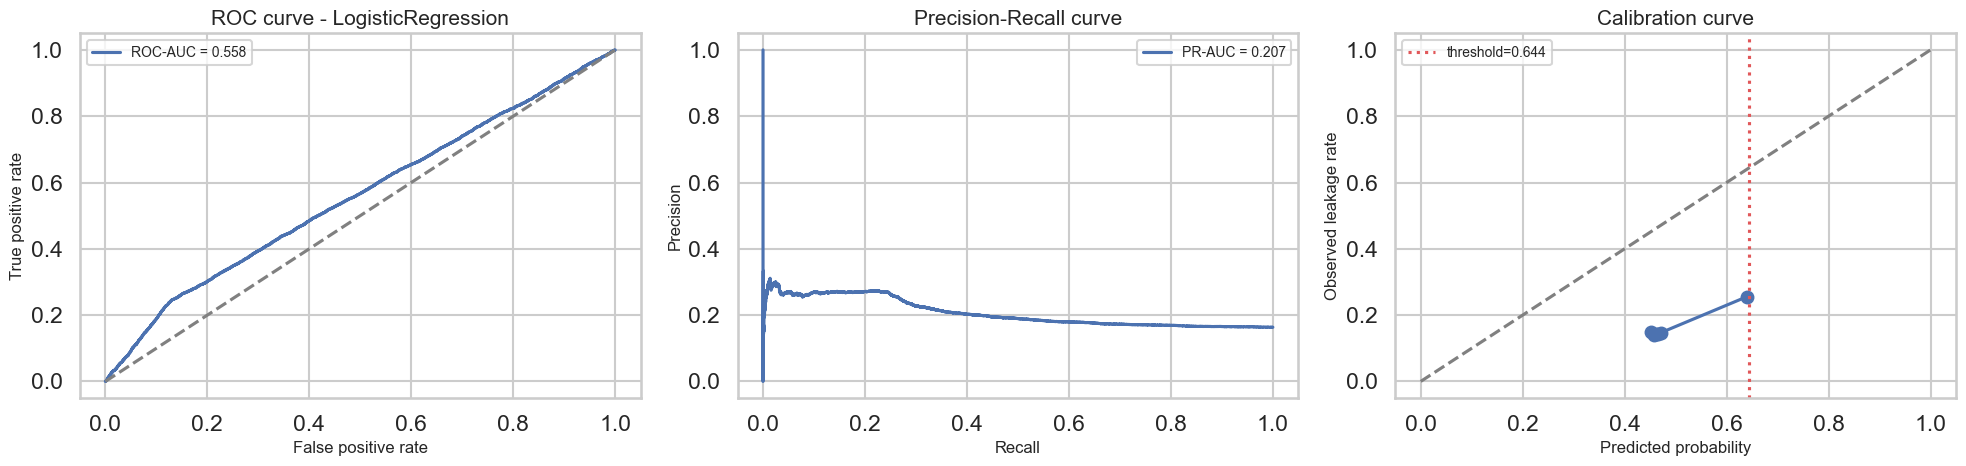

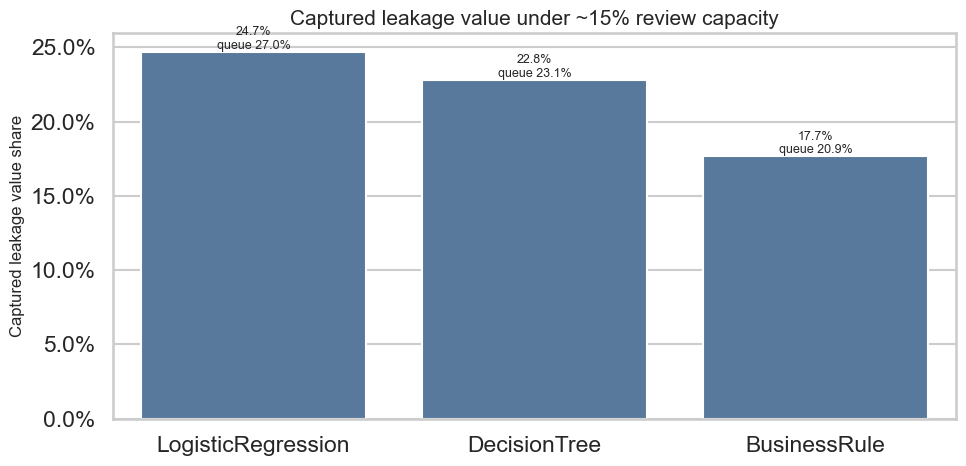

,risk_segment,orders,leakage_rate,avg_score,realized_net_revenue,leakage_value
0,high,4964,0.2683,0.6577,"123,610,826.6700","35,919,907.5300"
2,medium,6619,0.1475,0.4713,"198,565,493.8600","26,826,727.3800"
1,low,21511,0.1440,0.4590,"611,451,245.1400","80,561,547.1800"


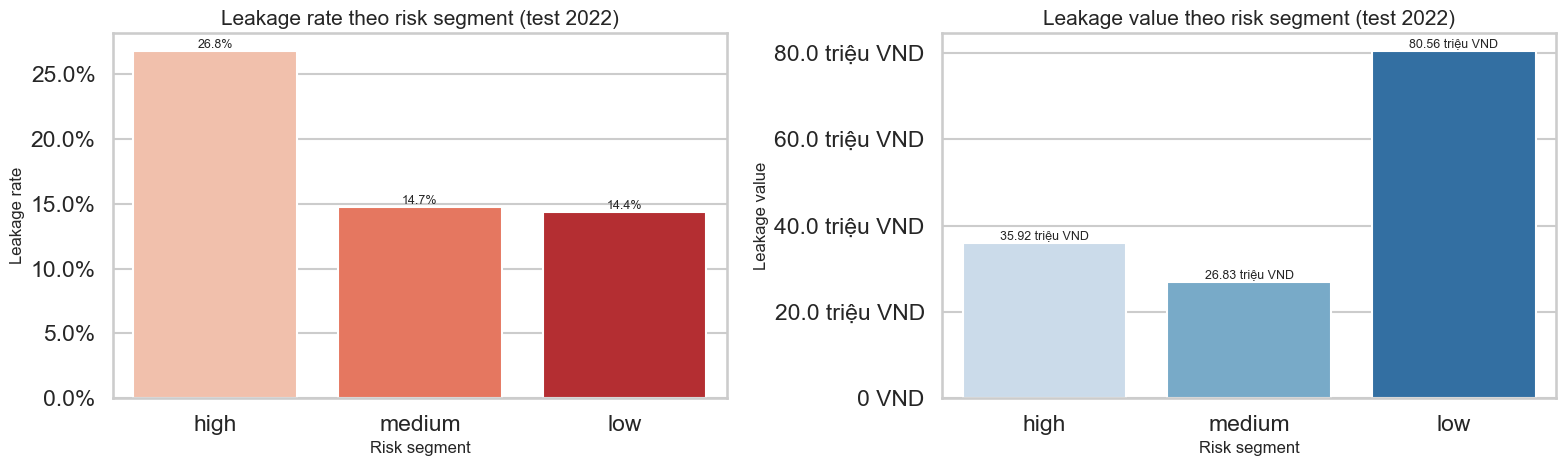

In [17]:
plot_model_diagnostics(modeling_result)
plot_review_capture(review_queue_df)

segment_df = build_risk_segments(modeling_result)
display(segment_df)
plot_risk_segments(segment_df)


In [18]:
primary_metrics = modeling_result["metrics"].iloc[0]
runner_up_metrics = modeling_result["metrics"].iloc[1]
rule_metrics = modeling_result["metrics"].loc[
    modeling_result["metrics"]["model"].eq("BusinessRule")
].iloc[0]

high_segment = segment_df.loc[segment_df["risk_segment"].eq("high")].iloc[0]
low_segment = segment_df.loc[segment_df["risk_segment"].eq("low")].iloc[0]
queue_headline = review_queue_df.iloc[0]

predictive_md = f'''
## Predictive takeaways
- Dưới ràng buộc review khoảng `{queue_headline['review_share']:.1%}` orders, **{primary_metrics['model']}** capture `{primary_metrics['captured_leakage_value_share']:.1%}` leakage value, nhỉnh hơn `{runner_up_metrics['model']}` ở mức `{runner_up_metrics['captured_leakage_value_share']:.1%}` nhưng chênh lệch **không quá lớn**.
- So với baseline `BusinessRule`, model chính vẫn tốt hơn về `captured leakage value share` (`{primary_metrics['captured_leakage_value_share']:.1%}` vs `{rule_metrics['captured_leakage_value_share']:.1%}`), nên đủ lý do để dùng như lớp triage bổ sung.
- Segment `high-risk` có leakage rate `{high_segment['leakage_rate']:.1%}`; tuy nhiên `low-risk` vẫn giữ `{low_segment['leakage_value']/1e6:.1f}` triệu VND leakage vì volume lớn. Vì vậy queue này dùng để **ưu tiên thứ tự review dưới capacity constraint**, không phải để bỏ qua các bucket còn lại.
- Feature interpretation cho thấy `payment method COD` là tín hiệu risk-up mạnh nhất, phù hợp với diagnostic story ở phần cancellation.
'''
display(Markdown(predictive_md))



## Predictive takeaways
- Dưới ràng buộc review khoảng `14.7%` orders, **LogisticRegression** capture `24.7%` leakage value, nhỉnh hơn `DecisionTree` ở mức `22.8%` nhưng chênh lệch **không quá lớn**.
- So với baseline `BusinessRule`, model chính vẫn tốt hơn về `captured leakage value share` (`24.7%` vs `17.7%`), nên đủ lý do để dùng như lớp triage bổ sung.
- Segment `high-risk` có leakage rate `26.8%`; tuy nhiên `low-risk` vẫn giữ `80.6` triệu VND leakage vì volume lớn. Vì vậy queue này dùng để **ưu tiên thứ tự review dưới capacity constraint**, không phải để bỏ qua các bucket còn lại.
- Feature interpretation cho thấy `payment method COD` là tín hiệu risk-up mạnh nhất, phù hợp với diagnostic story ở phần cancellation.


## 6. Prescriptive Analysis - What Should We Do?

Action plan bên dưới chỉ giữ 4 action có thể defend tốt nhất trước BGK. Mỗi action đều gắn trực tiếp với evidence ở phần diagnostic hoặc predictive và được lượng hóa theo `scope` + `recoverable leakage value`.


In [19]:
action_df = build_action_plan(
    fact_order=fact_order,
    cancel_methods=cancel_methods,
    size_ranking=size_ranking,
    promo_summary=promo_summary,
    review_queue_df=review_queue_df,
)
roi_df = simulate_action_roi(action_df)

print("Action library")
display(action_df)
print("Scenario table")
display(roi_df)


Action library


,action,driver,owner,kpi,scope_orders,scope_value,current_leakage_value,recoverable_low_value,recoverable_base_value,recoverable_high_value,monthly_upside_base,effort,timeline,assumption,evidence,priority_rank,priority_note
0,Giảm friction COD/cancellation,Cancellation friction,Checkout + CRM,Cancel rate của payment method hotspot,4920,"158,578,086.8400","27,796,069.9800","2,223,685.5984","4,169,410.4970","6,115,135.3956","347,450.8747",2.0000,30 ngày: chặn pain point checkout; 60 ngày: CR...,Recovery range 8%-15%-22% trên leakage hiện tạ...,Năm 2022: cod cancel rate 17.3% | share of can...,1,Ưu tiên 1: evidence mạnh + effort thấp
1,Size guidance + exchange flow,Wrong-size return,Merchandising + CX,Wrong-size refund value / wrong-size rate,6365,"265,627,312.3800","8,699,289.8800","1,304,893.4820","2,174,822.4700","3,044,751.4580","181,235.2058",2.5000,30 ngày: fit guide; 60 ngày: exchange-first fl...,Recovery range 15%-25%-35% trên leakage hiện t...,Năm 2022: Streetwear | size XL wrong-size rate...,2,Ưu tiên 2: bucket rõ + owner rõ
2,Risk review queue cho high-risk orders,Predictive triage,Ops + Risk,Captured leakage value share trong top review ...,4852,"155,879,547.0900","35,401,610.6200","1,770,080.5310","3,186,144.9558","4,956,225.4868","265,512.0797",3.2000,30 ngày: pilot manual review; 60 ngày: SLA que...,Recovery range 5%-9%-14% trên leakage hiện tại...,LogisticRegression capture 24.7% leakage value...,3,Ưu tiên 3: phù hợp khi capacity review hữu hạn
3,Promo guardrail theo bucket,Promotion erosion (proxy),Growth + Finance,Weighted margin delta promo vs no-promo,2163,"79,720,732.0800","15,356,948.8880","1,842,833.8666","3,071,389.7776","4,299,945.6886","255,949.1481",2.9000,30 ngày: freeze pilot bucket xấu; 60 ngày: gua...,Recovery range 12%-20%-28% trên leakage hiện t...,Năm 2022: Streetwear | organic_search margin d...,4,Ưu tiên 4: triển khai như pilot guardrail vì đ...


Scenario table


,action,scenario,owner,kpi,recoverable_value,monthly_upside
0,Giảm friction COD/cancellation,Conservative,Checkout + CRM,Cancel rate của payment method hotspot,"2,223,685.5984","185,307.1332"
1,Giảm friction COD/cancellation,Base,Checkout + CRM,Cancel rate của payment method hotspot,"4,169,410.4970","347,450.8747"
2,Giảm friction COD/cancellation,Aggressive,Checkout + CRM,Cancel rate của payment method hotspot,"6,115,135.3956","509,594.6163"
3,Size guidance + exchange flow,Conservative,Merchandising + CX,Wrong-size refund value / wrong-size rate,"1,304,893.4820","108,741.1235"
4,Size guidance + exchange flow,Base,Merchandising + CX,Wrong-size refund value / wrong-size rate,"2,174,822.4700","181,235.2058"
5,Size guidance + exchange flow,Aggressive,Merchandising + CX,Wrong-size refund value / wrong-size rate,"3,044,751.4580","253,729.2882"
6,Risk review queue cho high-risk orders,Conservative,Ops + Risk,Captured leakage value share trong top review ...,"1,770,080.5310","147,506.7109"
7,Risk review queue cho high-risk orders,Base,Ops + Risk,Captured leakage value share trong top review ...,"3,186,144.9558","265,512.0797"
8,Risk review queue cho high-risk orders,Aggressive,Ops + Risk,Captured leakage value share trong top review ...,"4,956,225.4868","413,018.7906"
9,Promo guardrail theo bucket,Conservative,Growth + Finance,Weighted margin delta promo vs no-promo,"1,842,833.8666","153,569.4889"


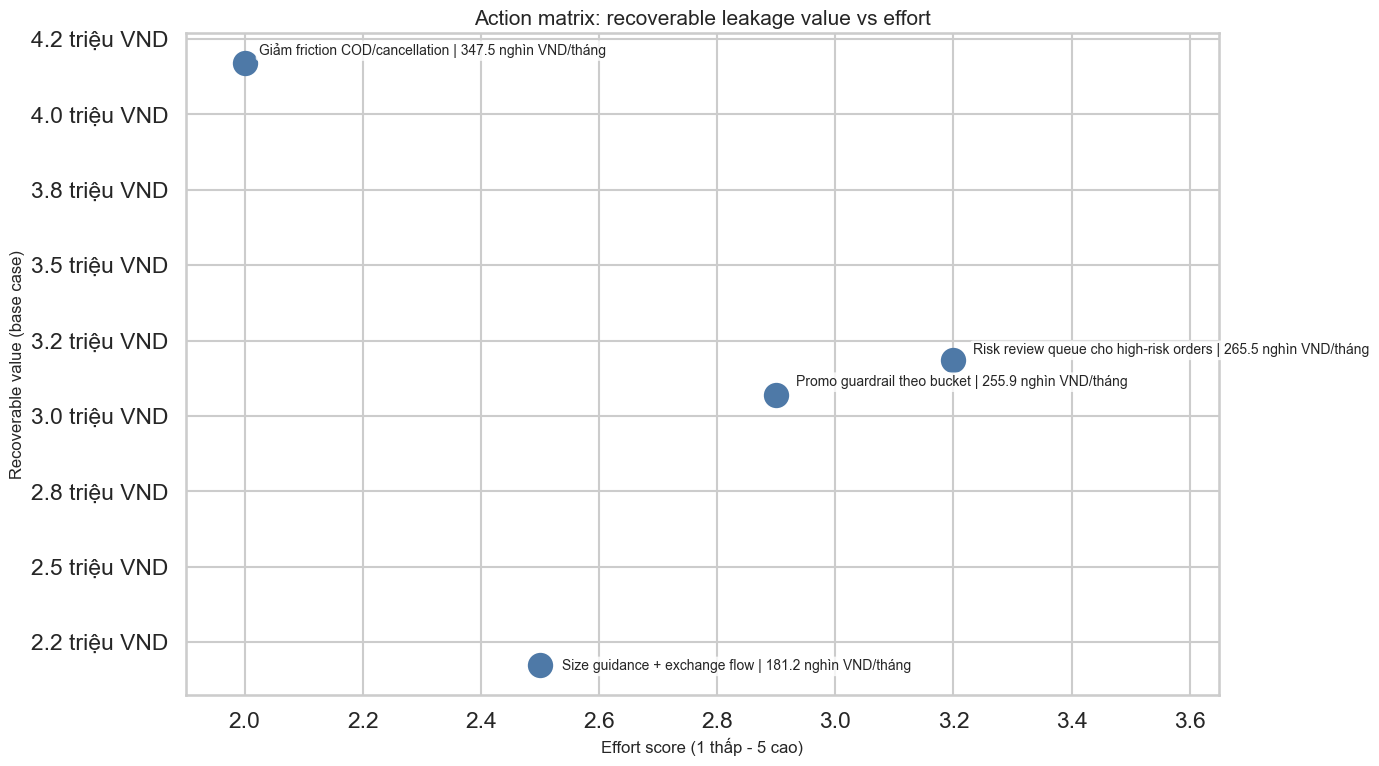

## Roadmap 30-60-90 ngày
- Các upside bên dưới được sizing trên scope năm `2022` và nên được đọc như `value-at-stake` để ưu tiên pilot, không phải forecast cam kết.
- **Ưu tiên 1 - Giảm friction COD/cancellation**: owner `Checkout + CRM` | KPI `Cancel rate của payment method hotspot` | base recoverable `4.17` triệu VND | Ưu tiên 1: evidence mạnh + effort thấp.
  Timeline: 30 ngày: chặn pain point checkout; 60 ngày: CRM nudge; 90 ngày: policy tuning theo source
- **Ưu tiên 2 - Size guidance + exchange flow**: owner `Merchandising + CX` | KPI `Wrong-size refund value / wrong-size rate` | base recoverable `2.17` triệu VND | Ưu tiên 2: bucket rõ + owner rõ.
  Timeline: 30 ngày: fit guide; 60 ngày: exchange-first flow; 90 ngày: optimize theo bucket
- **Ưu tiên 3 - Risk review queue cho high-risk orders**: owner `Ops + Risk` | KPI `Captured leakage value share trong top review bucket` | base recoverable `3.19` triệu VND | Ưu tiên 3: phù hợp khi capacity review hữu hạn.
  Timeline: 30 ngày: pilot manual review; 60 ngày: SLA queue; 90 ngày: semi-auto risk routing
- **Ưu tiên 4 - Promo guardrail theo bucket**: owner `Growth + Finance` | KPI `Weighted margin delta promo vs no-promo` | base recoverable `3.07` triệu VND | Ưu tiên 4: triển khai như pilot guardrail vì đây là proxy signal.
  Timeline: 30 ngày: freeze pilot bucket xấu; 60 ngày: guardrail margin; 90 ngày: scorecard theo promo bucket

In [20]:
plot_action_matrix(action_df)

roadmap_lines = [
    f"- Các upside bên dưới được sizing trên scope năm `{recent_year}` và nên được đọc như `value-at-stake` để ưu tiên pilot, không phải forecast cam kết."
]
for row in action_df.itertuples(index=False):
    roadmap_lines.append(
        f"- **Ưu tiên {row.priority_rank} - {row.action}**: owner `{row.owner}` | KPI `{row.kpi}` | "
        f"base recoverable `{row.recoverable_base_value/1e6:.2f}` triệu VND | {row.priority_note}.\n"
        f"  Timeline: {row.timeline}"
    )

roadmap_md = "## Roadmap 30-60-90 ngày\n" + "\n".join(roadmap_lines)
display(Markdown(roadmap_md))


In [21]:
executive_summary_md = build_executive_summary(
    descriptive_points=descriptive_points,
    root_cause_df=root_cause_df,
    metrics_df=modeling_result["metrics"],
    action_df=action_df,
    review_queue_df=review_queue_df,
)
display(Markdown(executive_summary_md))


## Executive Summary

### 1. Điều gì đang xảy ra?
- Năm 2022, realized net revenue đạt 933.63 triệu VND, thay đổi +12.3% YoY; tổng leakage value đạt 143.31 triệu VND (+11.5% YoY).
- Tháng mạnh nhất trong năm là 04/2022 với 113.15 triệu VND realized net revenue, trong khi tháng áp lực leakage cao nhất là 10/2022 ở mức 17.4%.
- Streetwear dẫn dắt 83.9% realized net revenue và 65.8% volume resolved của năm 2022; East đóng góp 46.6% realized net revenue, trong khi 91.9% flow của năm đã chốt outcome.

### 2. Vì sao đang xảy ra?
- Các driver dưới đây được nhận diện trên full-history resolved sample; phần action phía dưới được sizing theo scope năm gần nhất để tránh phóng đại upside.
- Cancellation friction: cod có cancel rate 16.9% và chiếm 26.0% cancel leakage (Full-history resolved sample | scope 91,443 orders | leakage 394.20 triệu VND).
- Wrong-size return: Streetwear | size XL có wrong-size rate 1.9% và chiếm 26.7% wrong-size refund (Full-history order-line sample | refund 47.19 triệu VND trên 121,243 order lines).
- Promotion erosion (proxy): So sánh matched theo tháng trong cùng category/source cho thấy Streetwear | organic_search có proxy margin delta -7.1 nghìn VND (Full-history 63 matched months | năm 2022 scope 1,890 promo orders | negative months 100%).

### 3. Triage layer nên vận hành ra sao?
- Dưới ràng buộc review khoảng 15% orders, LogisticRegression capture 24.7% leakage value, nhỉnh hơn DecisionTree (22.8%) nhưng chênh lệch không quá lớn.
- Queue nên ưu tiên high-risk bucket vì leakage rate tại queue đạt 27.0%; predictive được dùng như lớp triage, không thay thế business rule toàn phần.

### 4. Nên làm gì trong 30-60-90 ngày?
- Các upside bên dưới được sizing trên scope năm gần nhất và nên được đọc như value-at-stake để ưu tiên pilot, không phải forecast cam kết.
- Giảm friction COD/cancellation: base recoverable value ~ 4.17 triệu VND, monthly upside ~ 347.5 nghìn VND.
- Size guidance + exchange flow: base recoverable value ~ 2.17 triệu VND, monthly upside ~ 181.2 nghìn VND.
- Risk review queue cho high-risk orders: base recoverable value ~ 3.19 triệu VND, monthly upside ~ 265.5 nghìn VND.